### Integral Timescale and Velocity Uncertainty 

The main idea behind the integral timescale is to determine the effective degrees of freedom on the velocity data. Velocity data is inherently dominated by low frequency motion which leads to every sample not being fully indepenent of each other. 

Goal is to get confidence interval / uncertainty estimate for the mean velocity of a timeseries 


Analysis Steps: 

- Determine the integral timescale via autocorrelation 

- Estimate the effective degrees of freedom (N* = N delta T / integral timescale )

Functions to use: 

- integral_timescale_trapezoidal (follows definition of integral timescale in Emery and Thomson)
- standard_error_saunders (follows standard error estimate from Saunders (1987))

It's ok to just report the standard error as the error estimate on the mean velocity. Should try to do this for smaller timescales (i.e. monthly)

In [1]:
### imports
import numpy as np
import matplotlib.pyplot as plt 
import scipy 
import xarray as xr  
from TNB_tools import Integral_Timescale as its
import TNB_tools.tides.tidal_decomposition as tides

In [2]:
# # load in data - DELL 
# vel = xr.open_dataset("//thepenguin/penguin2/Data/TNB/mooring/LDEO/2018_19 Araon Cruise (ANA09B) - NIWAMooringRetrieval/Data/TNBD/working/tnbd_2018_vel_bot_1093.nc") 

# load data - MAC 
vel = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/tnbd_2018_vel_bot_1093.nc')

In [ ]:
# LOAD IN INTERMEDIATE DATASETS DELL - 30 MIN AVERAGED DATA 
TNBD_ctd_top = xr.open_dataset('data/TNBD_ctd_top_30min.nc')
TNBD_ctd_bot = xr.open_dataset('data/TNBD_ctd_bot_30min.nc')
TNBD_vel_top = xr.open_dataset('data/TNBD_vel_top_30min.nc')
TNBD_vel_bot = xr.open_dataset('data/TNBD_vel_bot_30min.nc')

DITD_ctd_top = xr.open_dataset('data/DITD_ctd_top_30min.nc')
DITD_ctd_bot = xr.open_dataset('data/DITD_ctd_bot_30min.nc')
DITD_vel_top = xr.open_dataset('data/DITD_vel_top_30min.nc')
DITD_vel_bot = xr.open_dataset('data/DITD_vel_bot_30min.nc')      # sensor cut out in june 2018

D_ctd_top = xr.open_dataset('data/D_ctd_top_30min.nc')
D_ctd_mid = xr.open_dataset('data/D_ctd_mid_30min.nc')
# D_ctd_bot = D_ctd_bot.sel(time=time_slice).resample(time=resample).mean()        # this sensor cut out in 2017

# D_vel_top = D_vel_top.sel(time=time_slice).resample(time=resample).mean()        # this sensor cut out end of 2017
D_vel_mid = xr.open_dataset('data/D_vel_mid_30min.nc')
D_vel_bot = xr.open_dataset('data/D_vel_bot_30min.nc')

In [3]:
its.check_gaps(vel)

Time series length: 28610 points
Median sampling interval: 900.0 s
u: 0 NaNs (0.00%)
v: 0 NaNs (0.00%)


{'n_points': 28610,
 'dt_median_s': 900.0,
 'n_irregular_steps': 4,
 'irregular_step_indices': array([28416, 28465, 28514, 28563]),
 'nan_counts': {'u': 0, 'v': 0}}

In [4]:
# cropping dataset in December 2018 to avoid weird timestamps 
vel = vel.sel(time=slice('2018-03','2018-12'))

In [5]:
its.check_gaps(vel)

Time series length: 28320 points
Median sampling interval: 900.0 s
Time sampling is regular.
u: 0 NaNs (0.00%)
v: 0 NaNs (0.00%)


{'n_points': 28320,
 'dt_median_s': 900.0,
 'n_irregular_steps': 0,
 'irregular_step_indices': array([], dtype=int64),
 'nan_counts': {'u': 0, 'v': 0}}

In [7]:
dt_seconds = 900

In [20]:
# defining how far out to do the lag for
nlags = int(70 * 86400 / dt_seconds)  # 70 days, in samples
rho = its.autocorrelation(vel.v, nlags=nlags)

In [21]:
dt_seconds = 900.0
lags_samples = np.arange(len(rho))
lags_hours = lags_samples * dt_seconds / 3600
lags_days = lags_samples * dt_seconds / 86400

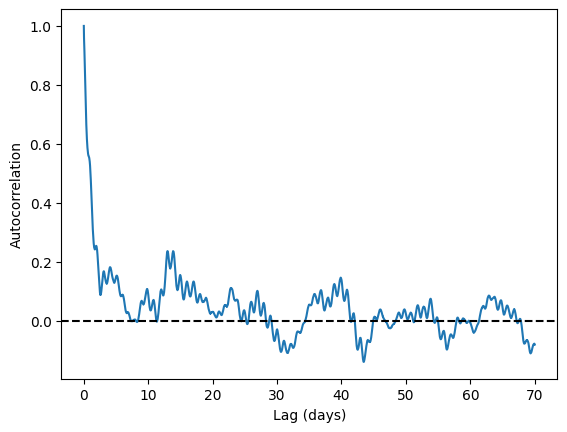

In [22]:
plt.plot(lags_days,rho)
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.axhline(y=0,color='k',ls='--')

In [23]:
T_l, zero_crossing = its.integral_timescale_trapezoidal(rho,dt_seconds)

In [24]:
T_l / 86400

1.605293089394366

In [25]:
# standard error
e = its.standard_error_saunders(sigma=np.std(vel.v),T_L=T_l,T_record=(len(vel.v)*dt_seconds))

In [27]:
np.mean(vel.v)

<xarray.DataArray 'v' ()> Size: 8B
array(-1.66512793)
Coordinates:
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...

In [26]:
e

<xarray.DataArray 'v' ()> Size: 8B
array(0.60329407)
Coordinates:
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...

In [16]:
effective_dof = its.effective_dof(N=len(vel.u), dt=dt_seconds,T_int=T_l)

In [17]:
effective_dof

93.86284543754323

In [18]:
nlags = int(70 * 86400 / dt_seconds)  # search within 70 days
results = {v: its.analyze_component(vel, v, dt_seconds, nlags=nlags) for v in ("u", "v")}


--- u ---
Integral timescale: 543090.5 s (150.86 hr), zero crossing at lag 1856
N = 28320, N* = 46.9
Mean u = -1.2247, 95% CI = (-2.8144, 0.3650)

--- v ---
Integral timescale: 277394.9 s (77.05 hr), zero crossing at lag 704
N = 28320, N* = 91.9
Mean v = -1.6651, 95% CI = (-2.8635, -0.4667)


In [19]:
its.compare_confidence_intervals(vel['v'].values, dt_seconds)

T_int (two-sided) = 277394.9, T_L (one-sided) = 138697.5
N* = 91.9
SE (ours, N*)       = 0.60331   -> 95% CI (-2.8635399336487013, -0.4667159218173631)
SE (Saunders, T_L)  = 0.60331   -> 95% CI (-2.847584029933924, -0.48267182553214005)
(SE values should match closely -- t vs. z multiplier is the main remaining difference, and matters more when N* is small)


{'mean': -1.6651279277330322,
 'T_int': 277394.91255521844,
 'T_L': 138697.45627760922,
 'N_star': 91.88344431128073,
 'se_ours': 0.6033050155655693,
 'ci_ours': (-2.8635399336487013, -0.4667159218173631),
 'se_saunders': 0.6033050155655691,
 'ci_saunders': (-2.847584029933924, -0.48267182553214005)}

### Integral timescale on low-passed filtered data 

In [52]:
lowpass_ds, highpass_ds = tides.decompose_tidal_dataset(
    vel, var_names=["u", "v"], window_days=1, sampling_hours=0.25
)

In [53]:
lowpass_ds

<xarray.Dataset> Size: 680kB
Dimensions:  (time: 28320)
Coordinates:
  * time     (time) datetime64[ns] 227kB 2018-03-12 ... 2018-12-31T23:45:00
    lat      float64 8B -75.01
    lon      float64 8B 165.6
    z        int64 8B 1093
Data variables:
    u        (time) float64 227kB nan nan nan nan nan ... nan nan nan nan nan
    v        (time) float64 227kB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    decomposition:  low-pass via cosine window, window_days=1, sampling_hours...

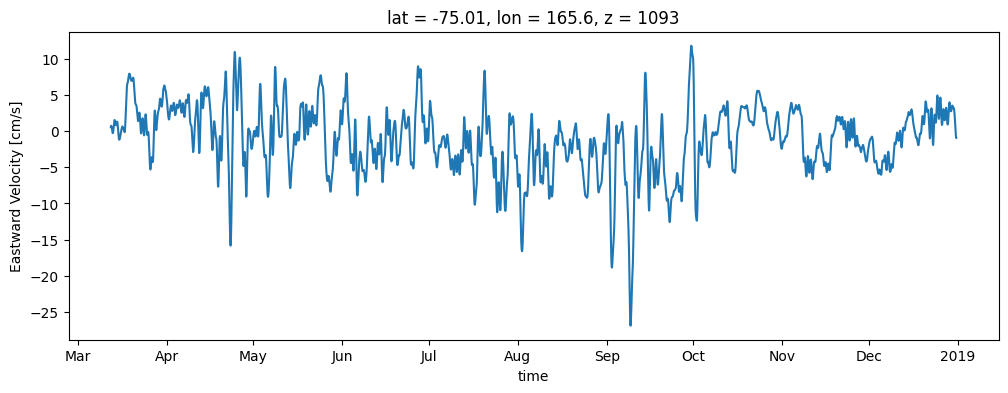

In [67]:
lowpass_ds.u.plot(figsize=(12,4))

In [54]:
# check data 
its.check_gaps(lowpass_ds.u)

Time series length: 28320 points
Median sampling interval: 900.0 s
Time sampling is regular.


{'n_points': 28320,
 'dt_median_s': 900.0,
 'n_irregular_steps': 0,
 'irregular_step_indices': array([], dtype=int64),
 'nan_counts': {}}

In [55]:
nan_mask = lowpass_ds["u"].isnull()
print(nan_mask.sum().item(), "total NaNs")
print(lowpass_ds["u"].time.where(nan_mask, drop=True).values)  # timestamps of NaNs

96 total NaNs
['2018-03-12T00:00:00.000000000' '2018-03-12T00:15:00.000000000'
 '2018-03-12T00:30:00.000000000' '2018-03-12T00:45:00.000000000'
 '2018-03-12T01:00:00.000000000' '2018-03-12T01:15:00.000000000'
 '2018-03-12T01:30:00.000000000' '2018-03-12T01:45:00.000000000'
 '2018-03-12T02:00:00.000000000' '2018-03-12T02:15:00.000000000'
 '2018-03-12T02:30:00.000000000' '2018-03-12T02:45:00.000000000'
 '2018-03-12T03:00:00.000000000' '2018-03-12T03:15:00.000000000'
 '2018-03-12T03:30:00.000000000' '2018-03-12T03:45:00.000000000'
 '2018-03-12T04:00:00.000000000' '2018-03-12T04:15:00.000000000'
 '2018-03-12T04:30:00.000000000' '2018-03-12T04:45:00.000000000'
 '2018-03-12T05:00:00.000000000' '2018-03-12T05:15:00.000000000'
 '2018-03-12T05:30:00.000000000' '2018-03-12T05:45:00.000000000'
 '2018-03-12T06:00:00.000000000' '2018-03-12T06:15:00.000000000'
 '2018-03-12T06:30:00.000000000' '2018-03-12T06:45:00.000000000'
 '2018-03-12T07:00:00.000000000' '2018-03-12T07:15:00.000000000'
 '2018-03-1

In [56]:
lowpass_clean = lowpass_ds["u"].dropna(dim="time")

In [57]:
lowpass_clean

<xarray.DataArray 'u' (time: 28224)> Size: 226kB
array([ 0.51721116,  0.55367866,  0.586614  , ..., -0.95388282,
       -0.95726911, -0.95800547])
Coordinates:
  * time     (time) datetime64[ns] 226kB 2018-03-12T12:00:00 ... 2018-12-31T1...
    lat      float64 8B -75.01
    lon      float64 8B 165.6
    z        int64 8B 1093
Attributes:
    long_name:  Eastward Velocity
    units:      cm/s
    filter:     cosine low-pass, window=97 samples

In [58]:
dt_seconds = 900

In [59]:
nlags = int(70 * 86400 / dt_seconds)  # 10 days, in samples
rho = its.autocorrelation(lowpass_clean, nlags=nlags)

In [60]:
dt_seconds = 900.0
lags_samples = np.arange(len(rho))
lags_hours = lags_samples * dt_seconds / 3600
lags_days = lags_samples * dt_seconds / 86400

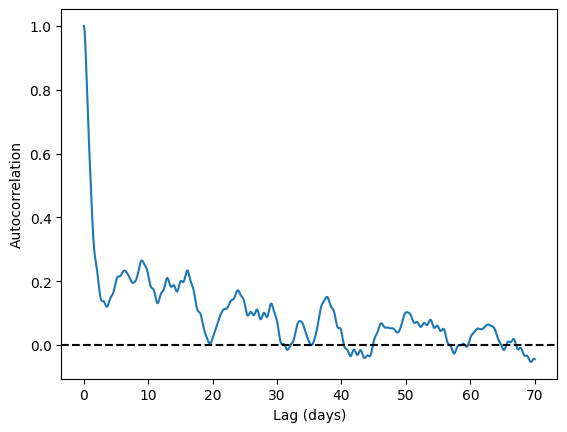

In [61]:
plt.plot(lags_days,rho)
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.axhline(y=0,color='k',ls='--')

In [62]:
T_l, zero_crossing = its.integral_timescale_trapezoidal(rho,dt_seconds)

In [63]:
# standard error
e = its.standard_error_saunders(sigma=np.std(lowpass_clean),T_L=T_l,T_record=(len(lowpass_clean)*dt_seconds))

In [64]:
e

<xarray.DataArray 'u' ()> Size: 8B
array(0.89025267)
Coordinates:
    lat      float64 8B -75.01
    lon      float64 8B 165.6
    z        int64 8B 1093

In [65]:
T_l / 86400

5.357108798501014

### progressive vector diagram 

In [67]:
import TNB_tools.pvd_tools as pvd

In [69]:
x,y = pvd.compute_pvd(vel.u/100,vel.v/100,dt=900)

<Axes: title={'center': 'Progressive Vector Diagram'}, xlabel='Eastward displacement (km)', ylabel='Northward displacement (km)'>

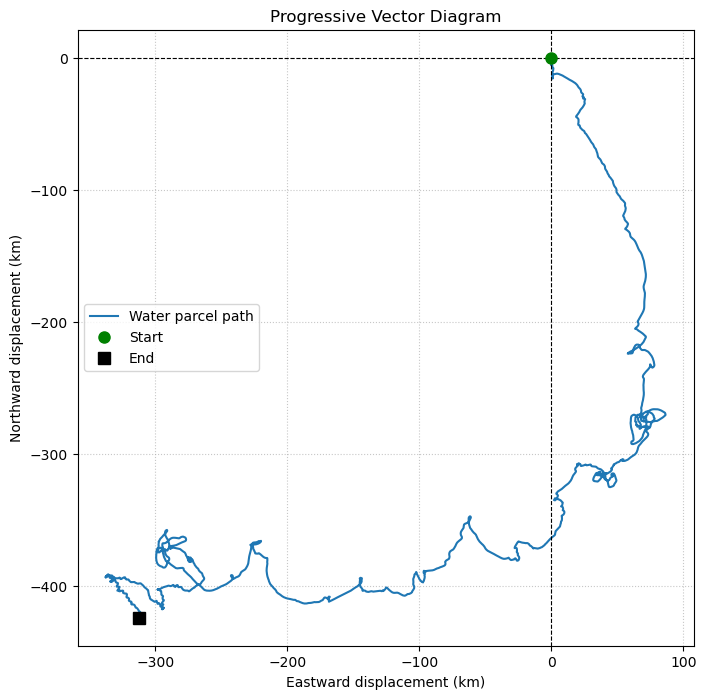

In [70]:
pvd.plot_pvd(x,y)

In [72]:
import pandas as pd

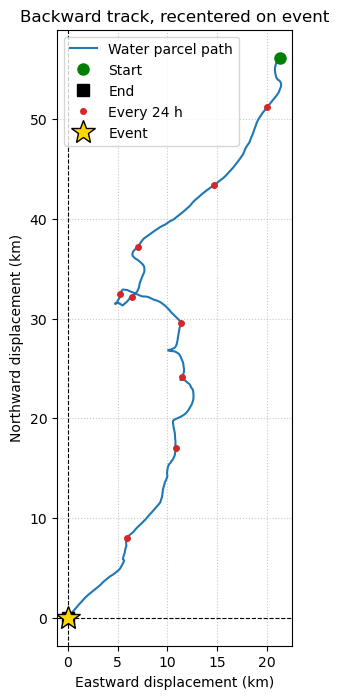

In [73]:
# x, y = compute_pvd(u_ms, v_ms, time=time, distance_units="km")
event_time = pd.Timestamp("2018-07-25T00:00")
event_idx = int(np.argmin(np.abs(pd.to_datetime(vel.time) - event_time)))
x_c, y_c = pvd.recenter_pvd(x, y, event_idx)
look_back = slice(max(0, event_idx - 960), event_idx + 1)  # ~10 days @ 900s
pvd.plot_pvd(x_c[look_back], y_c[look_back], time=vel.time[look_back],
            event_index=-1, event_label="Event",
            title="Backward track, recentered on event")
plt.show()

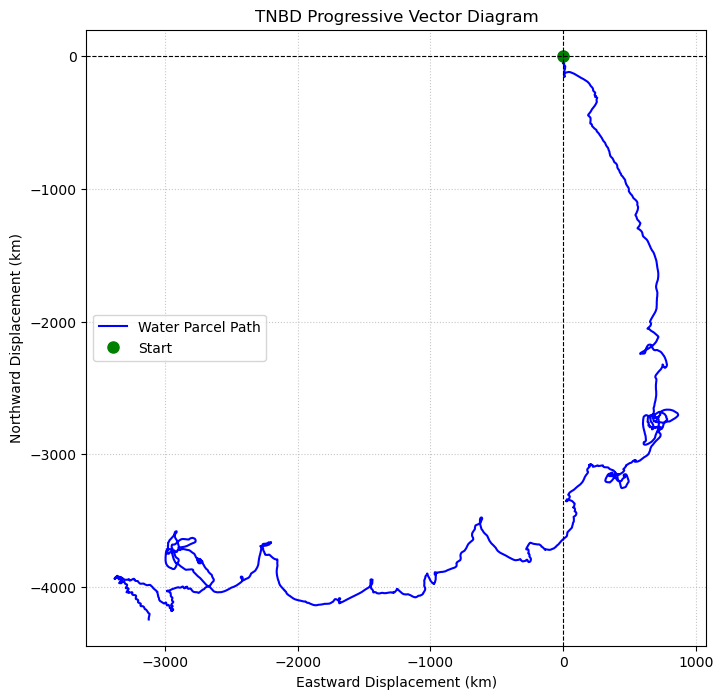

In [62]:
# 2. Convert velocity to displacement (distance = velocity * time)
hours = len(vel.u)*900 / 3600
dt = 900 # seconds
dx = vel.u /10000 * dt
dy = vel.v / 10000* dt

# 3. Calculate the cumulative sum to get the total path (x, y)
x_path = np.cumsum(dx)
y_path = np.cumsum(dy)

# 4. Plot the Progressive Vector Diagram
plt.figure(figsize=(8, 8))
plt.plot(x_path, y_path, color='blue', linewidth=1.5, label='Water Parcel Path')

# Mark the starting point
plt.plot(x_path[0], y_path[0], 'go', markersize=8, label='Start')

# # Add daily markers (24 hours * 3600 seconds = 86400 seconds)
# day_indices = np.arange(0, hours, 24)
# plt.plot(x_path[day_indices], y_path[day_indices], 'ro', markersize=4, label='Daily Mark')

# Formatting the plot
plt.title('TNBD Progressive Vector Diagram')
plt.xlabel('Eastward Displacement (km)')
plt.ylabel('Northward Displacement (km)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.axis('equal') # Ensures 1 meter East = 1 meter North visually
plt.show()

Text(0.5, 0, 'Time')

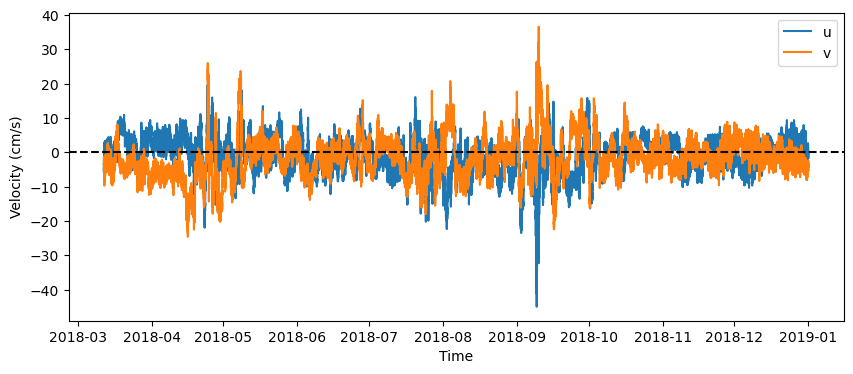

In [26]:
fig = plt.figure(figsize=(10,4))
plt.plot(vel.u.time,vel.u,label='u')
plt.plot(vel.v.time,vel.v,label='v')
plt.legend()
plt.axhline(y=0,color='k',ls='--')
plt.ylabel('Velocity (cm/s)')
plt.xlabel('Time')

### Estimates on all TNBD, DITD, and Mooring D 

In [ ]:
# load in all data 


In [2]:
import pandas as pd 

In [3]:
# load in DITD and D data - MAC
DITD_vel = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/vel_1100.nc')

TNBD_vel = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/tnbd_2018_vel_bot_1093.nc')

moorings = xr.open_datatree('/Users/mackenzie/Documents/Research/PhD/TNB_tools/preprocess/TNB_Moorings_DataTree.nc')

In [4]:
# fix DITD time - should save this change permenantly later
DITD_vel['time'] = DITD_vel.time - pd.Timedelta(12,'h')

In [5]:
# rename variables in DITD velocity dataset 
DITD_vel = DITD_vel.rename({
    'east':'u',
    'north':'v',
    'up':'w',
    'pressure':'pres',
    'direction':'dir'
}).assign_coords({
    'z':1121,
    'lat':-75.28,
    'lon':164.1
})
# # rename variables in DITD velocity dataset 
# DITD_vel_bot = DITD_vel_bot.rename({
#     'east':'u',
#     'north':'v',
#     'up':'w',
#     'pressure':'pres',
#     'direction':'dir'
# }).assign_coords({
#     'z':1218,
#     'lat':-75.28,
#     'lon':164.1
# })

In [6]:
D_vel = moorings['D/2017/vel/bot'].to_dataset().sel(time=slice('2018-01-01','2018-12-31'))

TNBD sampling interval is 15 min. DITD sampling interval is 10 min. D sampling interval is 30 min

In [7]:
DITD_vel['u'] = DITD_vel.u * 100
DITD_vel['v'] = DITD_vel.v * 100

In [11]:

# Mooring registry — update fs once you confirm sampling intervals
# from ds.time.diff('time').median()
moorings = {
    'TNBD': {'ds': TNBD_vel, 'fs': 1/900,  'color': 'steelblue', 'label': 'TNBD'},
    'DITD': {'ds': DITD_vel, 'fs': 1/600,  'color': 'tomato',    'label': 'DITD'},
    'D':    {'ds': D_vel,    'fs': 1/1800,  'color': 'seagreen',  'label': 'D'},
}

In [13]:
from TNB_tools.Integral_Timescale import (
    check_gaps,
    autocorrelation,
    integral_timescale_trapezoidal,
    one_sided_integral_timescale,
    effective_dof,
    standard_error_saunders,
    confidence_interval_mean,
)

MAX_LAG_DAYS = 70

timescale_results = {}

for name, m in moorings.items():
    ds = m['ds']
    dt = 1 / m['fs']
    u  = ds['u'].values
    v  = ds['v'].values
    N  = len(u)
    T_record = N * dt   # seconds

    nlags = int(MAX_LAG_DAYS * 86400 / dt)

    rho_u = autocorrelation(u, nlags=nlags)
    rho_v = autocorrelation(v, nlags=nlags)

    # Trapezoidal one-sided integral timescale (E&T convention)
    T_ET_u, k_star_u = integral_timescale_trapezoidal(rho_u, dt)
    T_ET_v, k_star_v = integral_timescale_trapezoidal(rho_v, dt)

    # Standard error on the mean (Saunders 1987)
    # Note: standard_error_saunders expects one-sided T_L
    # integral_timescale_trapezoidal already returns one-sided T, so use directly
    sigma_u   = u.std(ddof=1)
    sigma_v   = v.std(ddof=1)
    se_u      = standard_error_saunders(sigma_u, T_ET_u, T_record)
    se_v      = standard_error_saunders(sigma_v, T_ET_v, T_record)

    # N* for reference
    N_star_u  = effective_dof(N, dt, T_ET_u * 2)   # effective_dof expects two-sided T_int
    N_star_v  = effective_dof(N, dt, T_ET_v * 2)

    mean_u    = u.mean()
    mean_v    = v.mean()

    # 95% CI using normal approximation (Saunders style)
    from scipy.stats import norm
    z95 = norm.ppf(0.975)

    timescale_results[name] = {
        'lags_hours': np.arange(nlags + 1) * dt / 3600,
        'rho_u':      rho_u,
        'rho_v':      rho_v,
        'T_ET_u':     T_ET_u,
        'T_ET_v':     T_ET_v,
        'k_star_u':   k_star_u,
        'k_star_v':   k_star_v,
        'N_star_u':   N_star_u,
        'N_star_v':   N_star_v,
        'se_u':       se_u,
        'se_v':       se_v,
        'mean_u':     mean_u,
        'mean_v':     mean_v,
        'ci_u':       (mean_u - z95 * se_u, mean_u + z95 * se_u),
        'ci_v':       (mean_v - z95 * se_v, mean_v + z95 * se_v),
        'dt':         dt,
        'T_record_days': T_record / 86400,
    }

    print(f"\n{'='*45}")
    print(f"Mooring: {name}  (dt={dt:.0f}s, N={N}, "
          f"T_record={T_record/86400:.1f} days)")
    print(f"{'='*45}")
    for comp, T_ET, k_star, N_star, mean, se, ci in [
        ('u', T_ET_u, k_star_u, N_star_u, mean_u, se_u, timescale_results[name]['ci_u']),
        ('v', T_ET_v, k_star_v, N_star_v, mean_v, se_v, timescale_results[name]['ci_v']),
    ]:
        print(f"  {comp}: T_ET={T_ET/3600:.2f} hr  k*={k_star}  "
              f"N*={N_star:.0f}  mean={mean:.3f}  "
              f"SE={se:.4f}  95%CI=({ci[0]:.3f}, {ci[1]:.3f})")


Mooring: TNBD  (dt=900s, N=28610, T_record=298.0 days)
  u: T_ET=75.99 hr  k*=1857  N*=47  mean=-1.205  SE=0.7862  95%CI=(-2.746, 0.336)
  v: T_ET=38.58 hr  k*=703  N*=93  mean=-1.675  SE=0.5979  95%CI=(-2.847, -0.503)

Mooring: DITD  (dt=600s, N=42912, T_record=298.0 days)
  u: T_ET=56.83 hr  k*=2832  N*=63  mean=-1.446  SE=0.5993  95%CI=(-2.620, -0.271)
  v: T_ET=20.67 hr  k*=350  N*=173  mean=1.851  SE=0.3808  95%CI=(1.105, 2.597)

Mooring: D  (dt=1800s, N=17520, T_record=365.0 days)
  u: T_ET=72.70 hr  k*=889  N*=60  mean=7.810  SE=0.7786  95%CI=(6.284, 9.336)
  v: T_ET=111.36 hr  k*=1567  N*=39  mean=4.624  SE=0.9358  95%CI=(2.789, 6.458)


In [14]:
seasons = {
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11],
    'DJF': [12],
}
season_notes = {
    'MAM': 'Mar–May',
    'JJA': 'Jun–Aug',
    'SON': 'Sep–Nov',
    'DJF': 'Dec only',
}
season_order  = ['MAM', 'JJA', 'SON', 'DJF']
mooring_order = list(moorings.keys())

timescale_seasonal = {name: {} for name in mooring_order}

for name in mooring_order:
    ds = moorings[name]['ds']
    dt = 1 / moorings[name]['fs']

    print(f"\n{'='*45}")
    print(f"Mooring: {name}")
    print(f"{'='*45}")

    for season, months in seasons.items():
        seasonal  = ds.sel(time=ds.time.dt.month.isin(months))
        u         = seasonal['u'].values
        v         = seasonal['v'].values
        N         = len(u)
        T_record  = N * dt

        # Need enough lags to find zero crossing but can't exceed record
        nlags = min(int(MAX_LAG_DAYS * 86400 / dt), N // 2)

        if N < 2 * nlags:
            print(f"  {season}: only {N} samples, skipping")
            continue

        if np.any(np.isnan(u)) or np.any(np.isnan(v)):
            print(f"  {season}: NaNs present, skipping")
            continue

        try:
            rho_u = autocorrelation(u, nlags=nlags)
            rho_v = autocorrelation(v, nlags=nlags)

            T_ET_u, k_star_u = integral_timescale_trapezoidal(rho_u, dt)
            T_ET_v, k_star_v = integral_timescale_trapezoidal(rho_v, dt)
        except ValueError as e:
            print(f"  {season}: {e}")
            continue

        sigma_u  = u.std(ddof=1)
        sigma_v  = v.std(ddof=1)
        se_u     = standard_error_saunders(sigma_u, T_ET_u, T_record)
        se_v     = standard_error_saunders(sigma_v, T_ET_v, T_record)
        N_star_u = effective_dof(N, dt, T_ET_u * 2)
        N_star_v = effective_dof(N, dt, T_ET_v * 2)
        mean_u   = u.mean()
        mean_v   = v.mean()

        timescale_seasonal[name][season] = {
            'T_ET_u':    T_ET_u,
            'T_ET_v':    T_ET_v,
            'k_star_u':  k_star_u,
            'k_star_v':  k_star_v,
            'N_star_u':  N_star_u,
            'N_star_v':  N_star_v,
            'se_u':      se_u,
            'se_v':      se_v,
            'mean_u':    mean_u,
            'mean_v':    mean_v,
            'ci_u':      (mean_u - z95 * se_u, mean_u + z95 * se_u),
            'ci_v':      (mean_v - z95 * se_v, mean_v + z95 * se_v),
            'N':         N,
            'T_record_days': T_record / 86400,
        }

        print(f"  {season} ({season_notes[season]}, N={N}):")
        for comp, T_ET, k_star, N_star, mean, se in [
            ('u', T_ET_u, k_star_u, N_star_u, mean_u, se_u),
            ('v', T_ET_v, k_star_v, N_star_v, mean_v, se_v),
        ]:
            print(f"    {comp}: T_ET={T_ET/3600:.2f} hr  k*={k_star}  "
                  f"N*={N_star:.0f}  mean={mean:.3f}  SE={se:.4f}")


Mooring: TNBD
  MAM (Mar–May, N=7776):
    u: T_ET=13.28 hr  k*=136  N*=73  mean=0.984  SE=0.5880
    v: T_ET=84.50 hr  k*=1697  N*=12  mean=-3.859  SE=1.8301
  JJA (Jun–Aug, N=8832):
    u: T_ET=17.11 hr  k*=230  N*=65  mean=-2.692  SE=0.6137
    v: T_ET=24.74 hr  k*=298  N*=45  mean=-1.591  SE=0.8000
  SON (Sep–Nov, N=8736):
    u: T_ET=68.57 hr  k*=1928  N*=16  mean=-2.025  SE=1.5001
    v: T_ET=22.21 hr  k*=225  N*=49  mean=-0.162  SE=0.8386
  DJF (Dec only, N=2976):
    u: T_ET=53.23 hr  k*=628  N*=7  mean=-0.292  SE=1.3789
    v: T_ET=20.92 hr  k*=236  N*=18  mean=-0.568  SE=0.7827

Mooring: DITD
  MAM (Mar–May, N=11880):
    u: T_ET=29.82 hr  k*=524  N*=33  mean=-2.122  SE=0.6725
    v: T_ET=14.43 hr  k*=208  N*=69  mean=2.416  SE=0.4414
  JJA (Jun–Aug, N=13248):
    u: T_ET=26.88 hr  k*=483  N*=41  mean=-1.760  SE=0.8290
    v: T_ET=21.94 hr  k*=347  N*=50  mean=2.768  SE=0.7671
  SON (Sep–Nov, N=13104):
    u: T_ET=72.00 hr  k*=2186  N*=15  mean=-0.724  SE=1.3916
    v: T_ET=

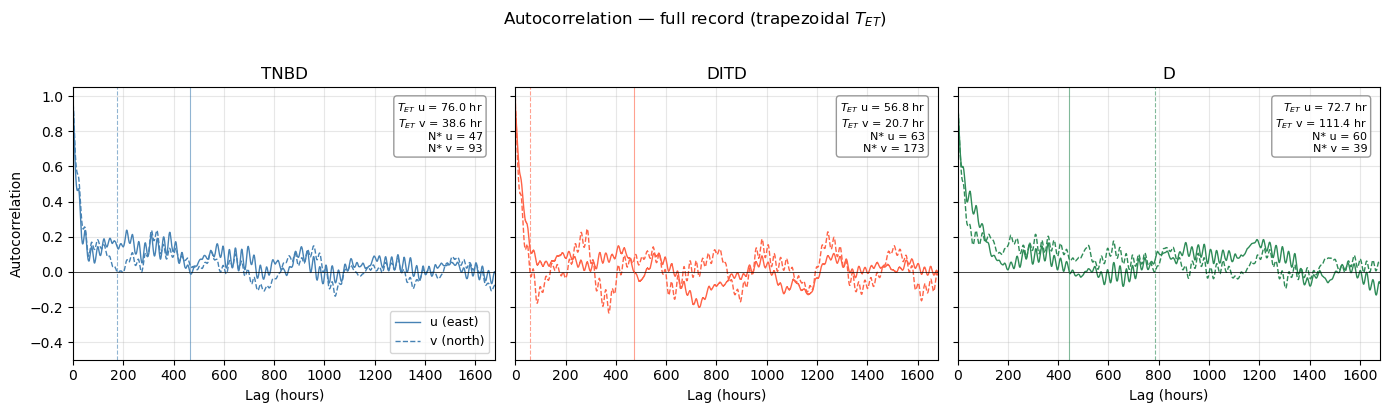

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (name, res) in zip(axes, timescale_results.items()):
    color = moorings[name]['color']
    lags  = res['lags_hours']

    ax.plot(lags, res['rho_u'], color=color, linewidth=1.0, label='u (east)')
    ax.plot(lags, res['rho_v'], color=color, linewidth=1.0, label='v (north)',
            linestyle='--')
    ax.axhline(0, color='k', linewidth=0.5)

    # Mark zero crossings
    for k_star, ls in [(res['k_star_u'], '-'), (res['k_star_v'], '--')]:
        ax.axvline(k_star * res['dt'] / 3600,
                   color=color, linestyle=ls, linewidth=0.8, alpha=0.6)

    T_u_hr = res['T_ET_u'] / 3600
    T_v_hr = res['T_ET_v'] / 3600
    ax.text(0.97, 0.95,
            f"$T_{{ET}}$ u = {T_u_hr:.1f} hr\n"
            f"$T_{{ET}}$ v = {T_v_hr:.1f} hr\n"
            f"N* u = {res['N_star_u']:.0f}\n"
            f"N* v = {res['N_star_v']:.0f}",
            transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='gray', alpha=0.8))

    ax.set_title(moorings[name]['label'])
    ax.set_xlabel('Lag (hours)')
    ax.set_xlim(0, MAX_LAG_DAYS * 24)
    ax.set_ylim(-0.5, 1.05)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Autocorrelation')
axes[0].legend(fontsize=9)
plt.suptitle('Autocorrelation — full record (trapezoidal $T_{ET}$)', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

# Full record table
rows = []
for name, res in timescale_results.items():
    for comp, T_ET, k_star, N_star, mean, se, ci in [
        ('u', res['T_ET_u'], res['k_star_u'], res['N_star_u'],
              res['mean_u'],  res['se_u'],     res['ci_u']),
        ('v', res['T_ET_v'], res['k_star_v'], res['N_star_v'],
              res['mean_v'],  res['se_v'],     res['ci_v']),
    ]:
        rows.append({
            'Mooring':       name,
            'Component':     comp,
            'T_ET (hr)':     round(T_ET / 3600, 2),
            'k* (lags)':     k_star,
            'N*':            round(N_star, 1),
            'Mean (cm/s)':   round(mean, 3),
            'SE (cm/s)':     round(se, 4),
            'CI lower':      round(ci[0], 3),
            'CI upper':      round(ci[1], 3),
        })

print("Full record")
display(pd.DataFrame(rows).set_index(['Mooring', 'Component']))

# Seasonal table
rows = []
for name in mooring_order:
    for season in season_order:
        if season not in timescale_seasonal[name]:
            continue
        res = timescale_seasonal[name][season]
        for comp, T_ET, k_star, N_star, mean, se, ci in [
            ('u', res['T_ET_u'], res['k_star_u'], res['N_star_u'],
                  res['mean_u'],  res['se_u'],     res['ci_u']),
            ('v', res['T_ET_v'], res['k_star_v'], res['N_star_v'],
                  res['mean_v'],  res['se_v'],     res['ci_v']),
        ]:
            rows.append({
                'Mooring':     name,
                'Season':      season,
                'Component':   comp,
                'N':           res['N'],
                'T_ET (hr)':   round(T_ET / 3600, 2),
                'k* (lags)':   k_star,
                'N*':          round(N_star, 1),
                'Mean (cm/s)': round(mean, 3),
                'SE (cm/s)':   round(se, 4),
                'CI lower':    round(ci[0], 3),
                'CI upper':    round(ci[1], 3),
            })

print("\nSeasonal")
display(pd.DataFrame(rows).set_index(['Mooring', 'Season', 'Component']))

Full record


T_ET (hr)  k* (lags)     N*  Mean (cm/s)  SE (cm/s)  \
Mooring Component                                                        
TNBD    u              75.99       1857   47.1       -1.205     0.7862   
        v              38.58        703   92.7       -1.675     0.5979   
DITD    u              56.83       2832   62.9       -1.446     0.5993   
        v              20.67        350  173.0        1.851     0.3808   
D       u              72.70        889   60.2        7.810     0.7786   
        v             111.36       1567   39.3        4.624     0.9358   

                   CI lower  CI upper  
Mooring Component                      
TNBD    u            -2.746     0.336  
        v            -2.847    -0.503  
DITD    u            -2.620    -0.271  
        v             1.105     2.597  
D       u             6.284     9.336  
        v             2.789     6.458


Seasonal


N  T_ET (hr)  k* (lags)    N*  Mean (cm/s)  \
Mooring Season Component                                                   
TNBD    MAM    u           7776      13.28        136  73.2        0.984   
               v           7776      84.50       1697  11.5       -3.859   
        JJA    u           8832      17.11        230  64.5       -2.692   
               v           8832      24.74        298  44.6       -1.591   
        SON    u           8736      68.57       1928  15.9       -2.025   
               v           8736      22.21        225  49.2       -0.162   
        DJF    u           2976      53.23        628   7.0       -0.292   
               v           2976      20.92        236  17.8       -0.568   
DITD    MAM    u          11880      29.82        524  33.2       -2.122   
               v          11880      14.43        208  68.6        2.416   
        JJA    u          13248      26.88        483  41.1       -1.760   
               v          13248      21.94        347  50.3        2.768   
        SON    u          13104      72.00       2186  15.2       -0.724   
               v          13104      18.54        323  58.9        0.879   
        DJF    u           4464       7.70        190  48.3       -0.788   
               v           4464      43.78        929   8.5        0.456   
D       MAM    u           4416      53.99        493  20.4        9.653   
               v           4416     100.53        785  11.0        7.029   
        JJA    u           4416      46.02        254  24.0        8.434   
               v           4416      15.79        107  69.9        2.672   
        SON    u           4368      21.69        164  50.3        5.041   
               v           4368      18.17        103  60.1        2.616   
        DJF    u           1488      12.46         65  29.9        8.455   
               v           1488      32.43        210  11.5        7.437   

                          SE (cm/s)  CI lower  CI upper  
Mooring Season Component                                 
TNBD    MAM    u             0.5880    -0.169     2.136  
               v             1.8301    -7.446    -0.272  
        JJA    u             0.6137    -3.894    -1.489  
               v             0.8000    -3.159    -0.023  
        SON    u             1.5001    -4.965     0.915  
               v             0.8386    -1.805     1.482  
        DJF    u             1.3789    -2.994     2.411  
               v             0.7827    -2.102     0.967  
DITD    MAM    u             0.6725    -3.440    -0.804  
               v             0.4414     1.551     3.281  
        JJA    u             0.8290    -3.385    -0.135  
               v             0.7671     1.264     4.271  
        SON    u             1.3916    -3.452     2.003  
               v             0.7683    -0.627     2.385  
        DJF    u             0.2795    -1.336    -0.241  
               v             0.9387    -1.384     2.296  
D       MAM    u             1.0591     7.578    11.729  
               v             1.3973     4.291     9.768  
        JJA    u             1.6129     5.272    11.595  
               v             0.7282     1.245     4.100  
        SON    u             0.7753     3.522     6.561  
               v             0.9165     0.819     4.412  
        DJF    u             0.6396     7.201     9.708  
               v             0.8684     5.735     9.139

### Rotate Mooring Velocities and estimate Integral timescale for along-trough flow 

In [10]:
def rotate_velocities(u, v, theta_deg):
    """
    Rotate (u=East, v=North) to (along-trough, across-trough).
    
    Sign convention: positive v_along points from mooring 1 toward mooring 2.
    Flip sign afterward if that's up-trough rather than toward shelf break.
    
    Parameters
    ----------
    u, v      : array-like, eastward and northward velocity (m/s)
    theta_deg : float, trough axis angle CCW from East
    
    Returns
    -------
    v_along, v_across : rotated velocity components (m/s)
    """
    theta = np.deg2rad(theta_deg)
    v_along  =  u * np.cos(theta) - v * np.sin(theta) # u_prime, positive towards shelf break 
    v_across = u * np.sin(theta) + v * np.cos(theta) # v_prime, positive towards land (NW direction)
    return v_along, v_across


In [11]:
# calculated in Transport_Calculation notebook, using same value here 
theta_deg = 34.5687 

In [12]:
DITD_v_along, DITD_v_across = rotate_velocities(DITD_vel.u, DITD_vel.v, theta_deg)
DITD_vel['u_prime'] = ('time',DITD_v_along.data)
DITD_vel['v_prime'] = ('time',DITD_v_across.data)

In [13]:
TNBD_v_along, TNBD_v_across = rotate_velocities(TNBD_vel.u, TNBD_vel.v, theta_deg)
TNBD_vel['u_prime'] = ('time',TNBD_v_along.data)
TNBD_vel['v_prime'] = ('time',TNBD_v_across.data)

In [14]:
D_v_along, D_v_across = rotate_velocities(D_vel.u, D_vel.v, theta_deg)
D_vel['u_prime'] = ('time',D_v_along.data)
D_vel['v_prime'] = ('time',D_v_across.data)

In [16]:

# Mooring registry — update fs once you confirm sampling intervals
# from ds.time.diff('time').median()
moorings = {
    'TNBD': {'ds': TNBD_vel, 'fs': 1/900,  'color': 'steelblue', 'label': 'TNBD'},
    'DITD': {'ds': DITD_vel, 'fs': 1/600,  'color': 'tomato',    'label': 'DITD'},
    'D':    {'ds': D_vel,    'fs': 1/1800,  'color': 'seagreen',  'label': 'D'},
}

In [17]:
from TNB_tools.Integral_Timescale import (
    check_gaps,
    autocorrelation,
    integral_timescale_trapezoidal,
    one_sided_integral_timescale,
    effective_dof,
    standard_error_saunders,
    confidence_interval_mean,
)

MAX_LAG_DAYS = 70

timescale_results = {}

for name, m in moorings.items():
    ds = m['ds']
    dt = 1 / m['fs']
    u  = ds['u_prime'].values
    v  = ds['v_prime'].values
    N  = len(u)
    T_record = N * dt   # seconds

    nlags = int(MAX_LAG_DAYS * 86400 / dt)

    rho_u = autocorrelation(u, nlags=nlags)
    rho_v = autocorrelation(v, nlags=nlags)

    # Trapezoidal one-sided integral timescale (E&T convention)
    T_ET_u, k_star_u = integral_timescale_trapezoidal(rho_u, dt)
    T_ET_v, k_star_v = integral_timescale_trapezoidal(rho_v, dt)

    # Standard error on the mean (Saunders 1987)
    # Note: standard_error_saunders expects one-sided T_L
    # integral_timescale_trapezoidal already returns one-sided T, so use directly
    sigma_u   = u.std(ddof=1)
    sigma_v   = v.std(ddof=1)
    se_u      = standard_error_saunders(sigma_u, T_ET_u, T_record)
    se_v      = standard_error_saunders(sigma_v, T_ET_v, T_record)

    # N* for reference
    N_star_u  = effective_dof(N, dt, T_ET_u * 2)   # effective_dof expects two-sided T_int
    N_star_v  = effective_dof(N, dt, T_ET_v * 2)

    mean_u    = u.mean()
    mean_v    = v.mean()

    # 95% CI using normal approximation (Saunders style)
    from scipy.stats import norm
    z95 = norm.ppf(0.975)

    timescale_results[name] = {
        'lags_hours': np.arange(nlags + 1) * dt / 3600,
        'rho_u':      rho_u,
        'rho_v':      rho_v,
        'T_ET_u':     T_ET_u,
        'T_ET_v':     T_ET_v,
        'k_star_u':   k_star_u,
        'k_star_v':   k_star_v,
        'N_star_u':   N_star_u,
        'N_star_v':   N_star_v,
        'se_u':       se_u,
        'se_v':       se_v,
        'mean_u':     mean_u,
        'mean_v':     mean_v,
        'ci_u':       (mean_u - z95 * se_u, mean_u + z95 * se_u),
        'ci_v':       (mean_v - z95 * se_v, mean_v + z95 * se_v),
        'dt':         dt,
        'T_record_days': T_record / 86400,
    }

    print(f"\n{'='*45}")
    print(f"Mooring: {name}  (dt={dt:.0f}s, N={N}, "
          f"T_record={T_record/86400:.1f} days)")
    print(f"{'='*45}")
    for comp, T_ET, k_star, N_star, mean, se, ci in [
        ('u', T_ET_u, k_star_u, N_star_u, mean_u, se_u, timescale_results[name]['ci_u']),
        ('v', T_ET_v, k_star_v, N_star_v, mean_v, se_v, timescale_results[name]['ci_v']),
    ]:
        print(f"  {comp}: T_ET={T_ET/3600:.2f} hr  k*={k_star}  "
              f"N*={N_star:.0f}  mean={mean:.3f}  "
              f"SE={se:.4f}  95%CI=({ci[0]:.3f}, {ci[1]:.3f})")


Mooring: TNBD  (dt=900s, N=28610, T_record=298.0 days)
  u: T_ET=137.91 hr  k*=3045  N*=26  mean=-0.042  SE=1.1020  95%CI=(-2.202, 2.118)
  v: T_ET=18.43 hr  k*=221  N*=194  mean=-2.063  SE=0.3980  95%CI=(-2.843, -1.283)

Mooring: DITD  (dt=600s, N=42912, T_record=298.0 days)
  u: T_ET=74.04 hr  k*=2996  N*=48  mean=-2.241  SE=0.6403  95%CI=(-3.496, -0.986)
  v: T_ET=19.87 hr  k*=347  N*=180  mean=0.704  SE=0.3936  95%CI=(-0.067, 1.475)

Mooring: D  (dt=1800s, N=17520, T_record=365.0 days)
  u: T_ET=49.73 hr  k*=829  N*=88  mean=3.808  SE=0.5559  95%CI=(2.718, 4.897)
  v: T_ET=108.03 hr  k*=1164  N*=41  mean=8.239  SE=1.0389  95%CI=(6.203, 10.275)


In [18]:
seasons = {
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11],
    'DJF': [12],
}
season_notes = {
    'MAM': 'Mar–May',
    'JJA': 'Jun–Aug',
    'SON': 'Sep–Nov',
    'DJF': 'Dec only',
}
season_order  = ['MAM', 'JJA', 'SON', 'DJF']
mooring_order = list(moorings.keys())

timescale_seasonal = {name: {} for name in mooring_order}

for name in mooring_order:
    ds = moorings[name]['ds']
    dt = 1 / moorings[name]['fs']

    print(f"\n{'='*45}")
    print(f"Mooring: {name}")
    print(f"{'='*45}")

    for season, months in seasons.items():
        seasonal  = ds.sel(time=ds.time.dt.month.isin(months))
        u         = seasonal['u_prime'].values
        v         = seasonal['v_prime'].values
        N         = len(u)
        T_record  = N * dt

        # Need enough lags to find zero crossing but can't exceed record
        nlags = min(int(MAX_LAG_DAYS * 86400 / dt), N // 2)

        if N < 2 * nlags:
            print(f"  {season}: only {N} samples, skipping")
            continue

        if np.any(np.isnan(u)) or np.any(np.isnan(v)):
            print(f"  {season}: NaNs present, skipping")
            continue

        try:
            rho_u = autocorrelation(u, nlags=nlags)
            rho_v = autocorrelation(v, nlags=nlags)

            T_ET_u, k_star_u = integral_timescale_trapezoidal(rho_u, dt)
            T_ET_v, k_star_v = integral_timescale_trapezoidal(rho_v, dt)
        except ValueError as e:
            print(f"  {season}: {e}")
            continue

        sigma_u  = u.std(ddof=1)
        sigma_v  = v.std(ddof=1)
        se_u     = standard_error_saunders(sigma_u, T_ET_u, T_record)
        se_v     = standard_error_saunders(sigma_v, T_ET_v, T_record)
        N_star_u = effective_dof(N, dt, T_ET_u * 2)
        N_star_v = effective_dof(N, dt, T_ET_v * 2)
        mean_u   = u.mean()
        mean_v   = v.mean()

        timescale_seasonal[name][season] = {
            'T_ET_u':    T_ET_u,
            'T_ET_v':    T_ET_v,
            'k_star_u':  k_star_u,
            'k_star_v':  k_star_v,
            'N_star_u':  N_star_u,
            'N_star_v':  N_star_v,
            'se_u':      se_u,
            'se_v':      se_v,
            'mean_u':    mean_u,
            'mean_v':    mean_v,
            'ci_u':      (mean_u - z95 * se_u, mean_u + z95 * se_u),
            'ci_v':      (mean_v - z95 * se_v, mean_v + z95 * se_v),
            'N':         N,
            'T_record_days': T_record / 86400,
        }

        print(f"  {season} ({season_notes[season]}, N={N}):")
        for comp, T_ET, k_star, N_star, mean, se in [
            ('u', T_ET_u, k_star_u, N_star_u, mean_u, se_u),
            ('v', T_ET_v, k_star_v, N_star_v, mean_v, se_v),
        ]:
            print(f"    {comp}: T_ET={T_ET/3600:.2f} hr  k*={k_star}  "
                  f"N*={N_star:.0f}  mean={mean:.3f}  SE={se:.4f}")


Mooring: TNBD
  MAM (Mar–May, N=7776):
    u: T_ET=69.88 hr  k*=1778  N*=14  mean=3.000  SE=1.3834
    v: T_ET=18.85 hr  k*=220  N*=52  mean=-2.619  SE=0.8494
  JJA (Jun–Aug, N=8832):
    u: T_ET=21.46 hr  k*=242  N*=51  mean=-1.314  SE=0.7041
    v: T_ET=21.02 hr  k*=309  N*=53  mean=-2.837  SE=0.7215
  SON (Sep–Nov, N=8736):
    u: T_ET=36.42 hr  k*=639  N*=30  mean=-1.576  SE=1.1050
    v: T_ET=16.42 hr  k*=139  N*=67  mean=-1.282  SE=0.7129
  DJF (Dec only, N=2976):
    u: T_ET=93.23 hr  k*=982  N*=4  mean=0.082  SE=1.8288
    v: T_ET=3.98 hr  k*=32  N*=94  mean=-0.633  SE=0.3403

Mooring: DITD
  MAM (Mar–May, N=11880):
    u: T_ET=35.38 hr  k*=620  N*=28  mean=-3.118  SE=0.6513
    v: T_ET=14.23 hr  k*=202  N*=70  mean=0.786  SE=0.4871
  JJA (Jun–Aug, N=13248):
    u: T_ET=29.11 hr  k*=480  N*=38  mean=-3.020  SE=0.7620
    v: T_ET=21.44 hr  k*=350  N*=51  mean=1.281  SE=0.8339
  SON (Sep–Nov, N=13104):
    u: T_ET=25.81 hr  k*=413  N*=42  mean=-1.095  SE=0.8005
    v: T_ET=20.51

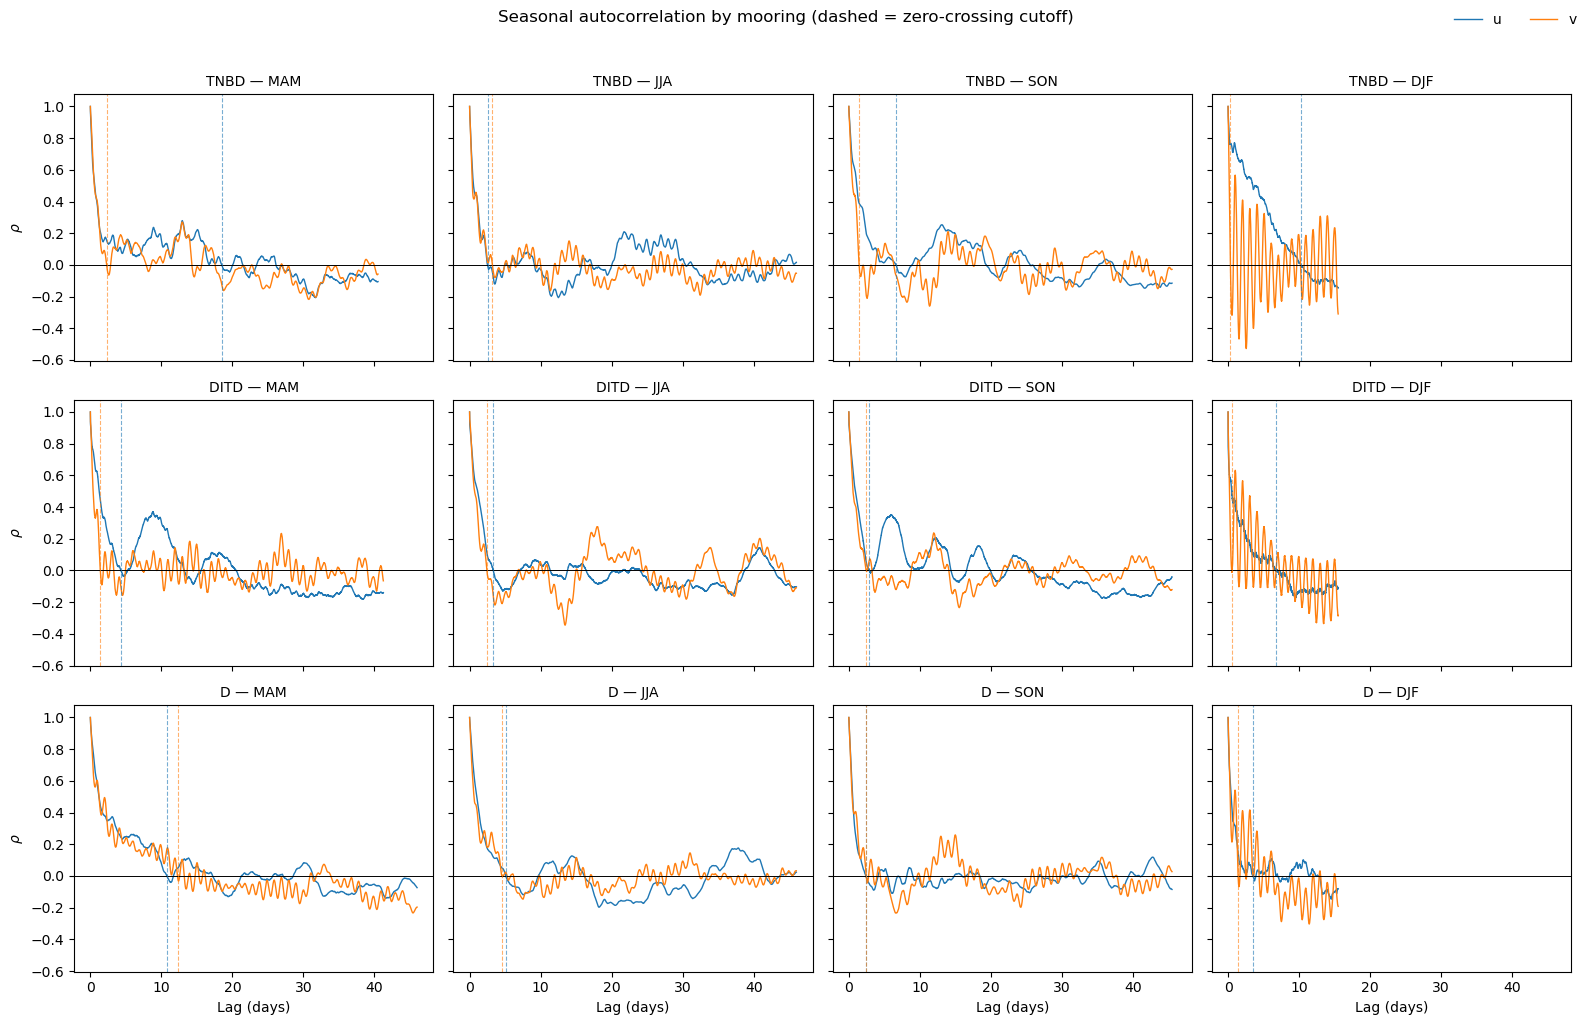

In [19]:
fig, axes = plt.subplots(len(mooring_order), len(season_order),
                          figsize=(16, 10), sharex=True, sharey=True)

for i, name in enumerate(mooring_order):
    ds = moorings[name]['ds']
    dt = 1 / moorings[name]['fs']

    for j, season in enumerate(season_order):
        ax = axes[i, j]
        months = seasons[season]
        seasonal = ds.sel(time=ds.time.dt.month.isin(months))
        u = seasonal['u_prime'].values
        v = seasonal['v_prime'].values
        N = len(u)

        nlags = min(int(MAX_LAG_DAYS * 86400 / dt), N // 2)

        # same skip logic as the timescale-computation cell
        if N < 2 * nlags or np.any(np.isnan(u)) or np.any(np.isnan(v)):
            ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='gray')
            ax.set_title(f"{name} — {season}", fontsize=10)
            continue

        rho_u = autocorrelation(u, nlags=nlags)
        rho_v = autocorrelation(v, nlags=nlags)
        lag_days = np.arange(len(rho_u)) * dt / 86400

        # pull the already-computed k_star / T_ET from the stored results
        # (recomputed rho here just for plotting, so these should match)
        res = timescale_seasonal[name].get(season)

        ax.plot(lag_days, rho_u, color='tab:blue', lw=1, label='u')
        ax.plot(lag_days, rho_v, color='tab:orange', lw=1, label='v')
        ax.axhline(0, color='k', lw=0.7)

        if res is not None:
            k_star_u_days = res['k_star_u'] * dt / 86400
            k_star_v_days = res['k_star_v'] * dt / 86400
            ax.axvline(k_star_u_days, color='tab:blue', lw=0.8, ls='--', alpha=0.6)
            ax.axvline(k_star_v_days, color='tab:orange', lw=0.8, ls='--', alpha=0.6)

        ax.set_title(f"{name} — {season}", fontsize=10)

        if i == len(mooring_order) - 1:
            ax.set_xlabel('Lag (days)')
        if j == 0:
            ax.set_ylabel(r'$\rho$')

# single shared legend instead of repeating per-panel
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper right', ncol=2, frameon=False)

fig.suptitle('Seasonal autocorrelation by mooring (dashed = zero-crossing cutoff)', y=1.02)
plt.tight_layout()
plt.show()

### Repeat Analysis on Rotated Velocity but use low pass filtered data to remove tidal effects 

In [20]:
from TNB_tools.tides.tidal_decomposition import decompose_tidal_dataset

In [24]:
# using functions 
TNBD_lowpass_ds, TNBD_highpass_ds = decompose_tidal_dataset(
    TNBD_vel, var_names=["u_prime", "v_prime"], window_days=2, sampling_hours=0.25
)


DITD_lowpass_ds, DITD_highpass_ds = decompose_tidal_dataset(
    DITD_vel, var_names=["u_prime", "v_prime"], window_days=2, sampling_hours=0.25
)

D_lowpass_ds, D_highpass_ds = decompose_tidal_dataset(
    D_vel, var_names=["u_prime", "v_prime"], window_days=2, sampling_hours=0.25
)

In [34]:
TNBD_lowpass_ds = TNBD_lowpass_ds.dropna(dim='time')
DITD_lowpass_ds = DITD_lowpass_ds.dropna(dim='time')
D_lowpass_ds = D_lowpass_ds.dropna(dim='time')

In [35]:
# Mooring registry — update fs once you confirm sampling intervals
# from ds.time.diff('time').median()
moorings = {
    'TNBD': {'ds': TNBD_lowpass_ds, 'fs': 1/900,  'color': 'steelblue', 'label': 'TNBD'},
    'DITD': {'ds': DITD_lowpass_ds, 'fs': 1/600,  'color': 'tomato',    'label': 'DITD'},
    'D':    {'ds': D_lowpass_ds,    'fs': 1/1800,  'color': 'seagreen',  'label': 'D'},
}

In [36]:
from TNB_tools.Integral_Timescale import (
    check_gaps,
    autocorrelation,
    integral_timescale_trapezoidal,
    one_sided_integral_timescale,
    effective_dof,
    standard_error_saunders,
    confidence_interval_mean,
)

MAX_LAG_DAYS = 70

timescale_results = {}

for name, m in moorings.items():
    ds = m['ds']
    dt = 1 / m['fs']
    u  = ds['u_prime'].values
    v  = ds['v_prime'].values
    N  = len(u)
    T_record = N * dt   # seconds

    nlags = int(MAX_LAG_DAYS * 86400 / dt)

    rho_u = autocorrelation(u, nlags=nlags)
    rho_v = autocorrelation(v, nlags=nlags)

    # Trapezoidal one-sided integral timescale (E&T convention)
    T_ET_u, k_star_u = integral_timescale_trapezoidal(rho_u, dt)
    T_ET_v, k_star_v = integral_timescale_trapezoidal(rho_v, dt)

    # Standard error on the mean (Saunders 1987)
    # Note: standard_error_saunders expects one-sided T_L
    # integral_timescale_trapezoidal already returns one-sided T, so use directly
    sigma_u   = u.std(ddof=1)
    sigma_v   = v.std(ddof=1)
    se_u      = standard_error_saunders(sigma_u, T_ET_u, T_record)
    se_v      = standard_error_saunders(sigma_v, T_ET_v, T_record)

    # N* for reference
    N_star_u  = effective_dof(N, dt, T_ET_u * 2)   # effective_dof expects two-sided T_int
    N_star_v  = effective_dof(N, dt, T_ET_v * 2)

    mean_u    = u.mean()
    mean_v    = v.mean()

    # 95% CI using normal approximation (Saunders style)
    from scipy.stats import norm
    z95 = norm.ppf(0.975)

    timescale_results[name] = {
        'lags_hours': np.arange(nlags + 1) * dt / 3600,
        'rho_u':      rho_u,
        'rho_v':      rho_v,
        'T_ET_u':     T_ET_u,
        'T_ET_v':     T_ET_v,
        'k_star_u':   k_star_u,
        'k_star_v':   k_star_v,
        'N_star_u':   N_star_u,
        'N_star_v':   N_star_v,
        'se_u':       se_u,
        'se_v':       se_v,
        'mean_u':     mean_u,
        'mean_v':     mean_v,
        'ci_u':       (mean_u - z95 * se_u, mean_u + z95 * se_u),
        'ci_v':       (mean_v - z95 * se_v, mean_v + z95 * se_v),
        'dt':         dt,
        'T_record_days': T_record / 86400,
    }

    print(f"\n{'='*45}")
    print(f"Mooring: {name}  (dt={dt:.0f}s, N={N}, "
          f"T_record={T_record/86400:.1f} days)")
    print(f"{'='*45}")
    for comp, T_ET, k_star, N_star, mean, se, ci in [
        ('u', T_ET_u, k_star_u, N_star_u, mean_u, se_u, timescale_results[name]['ci_u']),
        ('v', T_ET_v, k_star_v, N_star_v, mean_v, se_v, timescale_results[name]['ci_v']),
    ]:
        print(f"  {comp}: T_ET={T_ET/3600:.2f} hr  k*={k_star}  "
              f"N*={N_star:.0f}  mean={mean:.3f}  "
              f"SE={se:.4f}  95%CI=({ci[0]:.3f}, {ci[1]:.3f})")


Mooring: TNBD  (dt=900s, N=28418, T_record=296.0 days)
  u: T_ET=214.35 hr  k*=3907  N*=17  mean=-0.060  SE=1.1537  95%CI=(-2.321, 2.202)
  v: T_ET=41.32 hr  k*=707  N*=86  mean=-2.063  SE=0.4606  95%CI=(-2.966, -1.160)

Mooring: DITD  (dt=600s, N=42720, T_record=296.7 days)
  u: T_ET=108.93 hr  k*=3908  N*=33  mean=-2.243  SE=0.6841  95%CI=(-3.583, -0.902)
  v: T_ET=28.14 hr  k*=403  N*=126  mean=0.703  SE=0.3937  95%CI=(-0.069, 1.474)

Mooring: D  (dt=1800s, N=17328, T_record=361.0 days)
  u: T_ET=93.32 hr  k*=805  N*=46  mean=3.811  SE=0.5582  95%CI=(2.717, 4.905)
  v: T_ET=275.75 hr  k*=2732  N*=16  mean=8.207  SE=1.2791  95%CI=(5.700, 10.714)


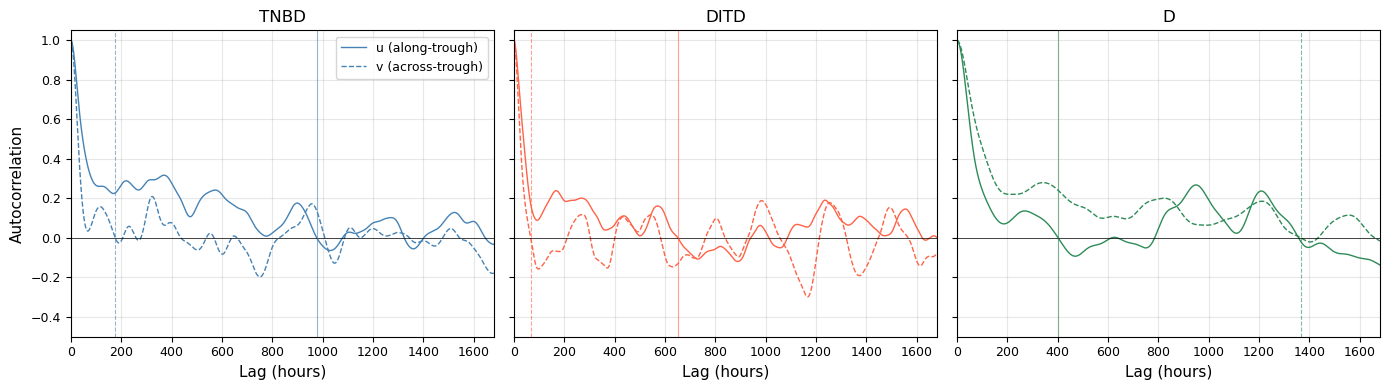

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (name, res) in zip(axes, timescale_results.items()):
    color = moorings[name]['color']
    lags  = res['lags_hours']

    ax.plot(lags, res['rho_u'], color=color, linewidth=1.0, label='u (along-trough)')
    ax.plot(lags, res['rho_v'], color=color, linewidth=1.0, label='v (across-trough)',
            linestyle='--')
    ax.axhline(0, color='k', linewidth=0.5)

    # Mark zero crossings
    for k_star, ls in [(res['k_star_u'], '-'), (res['k_star_v'], '--')]:
        ax.axvline(k_star * res['dt'] / 3600,
                   color=color, linestyle=ls, linewidth=0.8, alpha=0.6)

    T_u_hr = res['T_ET_u'] / 3600
    T_v_hr = res['T_ET_v'] / 3600
    # ax.text(0.97, 0.95,
    #         f"$T_{{ET}}$ u = {T_u_hr:.1f} hr\n"
    #         f"$T_{{ET}}$ v = {T_v_hr:.1f} hr\n"
    #         f"N* u = {res['N_star_u']:.0f}\n"
    #         f"N* v = {res['N_star_v']:.0f}",
    #         transform=ax.transAxes,
    #         ha='right', va='top', fontsize=8,
    #         bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
    #                   edgecolor='gray', alpha=0.8))

    ax.set_title(moorings[name]['label'])
    ax.set_xlabel('Lag (hours)')
    ax.set_xlim(0, MAX_LAG_DAYS * 24)
    ax.set_ylim(-0.5, 1.05)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Autocorrelation')
axes[0].legend(fontsize=9)
# plt.suptitle('Autocorrelation — full record (trapezoidal $T_{ET}$)', y=1.02)
plt.tight_layout()
# plt.savefig('FullRecord_IntegralTimescale.png', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
seasons = {
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11],
    'DJF': [12],
}
season_notes = {
    'MAM': 'Mar–May',
    'JJA': 'Jun–Aug',
    'SON': 'Sep–Nov',
    'DJF': 'Dec only',
}
season_order  = ['MAM', 'JJA', 'SON', 'DJF']
mooring_order = list(moorings.keys())

timescale_seasonal = {name: {} for name in mooring_order}

for name in mooring_order:
    ds = moorings[name]['ds']
    dt = 1 / moorings[name]['fs']

    print(f"\n{'='*45}")
    print(f"Mooring: {name}")
    print(f"{'='*45}")

    for season, months in seasons.items():
        seasonal  = ds.sel(time=ds.time.dt.month.isin(months))
        u         = seasonal['u_prime'].values
        v         = seasonal['v_prime'].values
        N         = len(u)
        T_record  = N * dt

        # Need enough lags to find zero crossing but can't exceed record
        nlags = min(int(MAX_LAG_DAYS * 86400 / dt), N // 2)

        if N < 2 * nlags:
            print(f"  {season}: only {N} samples, skipping")
            continue

        if np.any(np.isnan(u)) or np.any(np.isnan(v)):
            print(f"  {season}: NaNs present, skipping")
            continue

        try:
            rho_u = autocorrelation(u, nlags=nlags)
            rho_v = autocorrelation(v, nlags=nlags)

            T_ET_u, k_star_u = integral_timescale_trapezoidal(rho_u, dt)
            T_ET_v, k_star_v = integral_timescale_trapezoidal(rho_v, dt)
        except ValueError as e:
            print(f"  {season}: {e}")
            continue

        sigma_u  = u.std(ddof=1)
        sigma_v  = v.std(ddof=1)
        se_u     = standard_error_saunders(sigma_u, T_ET_u, T_record)
        se_v     = standard_error_saunders(sigma_v, T_ET_v, T_record)
        N_star_u = effective_dof(N, dt, T_ET_u * 2)
        N_star_v = effective_dof(N, dt, T_ET_v * 2)
        mean_u   = u.mean()
        mean_v   = v.mean()

        timescale_seasonal[name][season] = {
            'T_ET_u':    T_ET_u,
            'T_ET_v':    T_ET_v,
            'k_star_u':  k_star_u,
            'k_star_v':  k_star_v,
            'N_star_u':  N_star_u,
            'N_star_v':  N_star_v,
            'se_u':      se_u,
            'se_v':      se_v,
            'mean_u':    mean_u,
            'mean_v':    mean_v,
            'ci_u':      (mean_u - z95 * se_u, mean_u + z95 * se_u),
            'ci_v':      (mean_v - z95 * se_v, mean_v + z95 * se_v),
            'N':         N,
            'T_record_days': T_record / 86400,
        }

        print(f"  {season} ({season_notes[season]}, N={N}):")
        for comp, T_ET, k_star, N_star, mean, se in [
            ('u', T_ET_u, k_star_u, N_star_u, mean_u, se_u),
            ('v', T_ET_v, k_star_v, N_star_v, mean_v, se_v),
        ]:
            print(f"    {comp}: T_ET={T_ET/3600:.2f} hr  k*={k_star}  "
                  f"N*={N_star:.0f}  mean={mean:.3f}  SE={se:.4f}")


Mooring: TNBD
  MAM (Mar–May, N=7680):
    u: T_ET=116.68 hr  k*=1776  N*=8  mean=3.010  SE=1.3959
    v: T_ET=78.13 hr  k*=1692  N*=12  mean=-2.601  SE=1.3758
  JJA (Jun–Aug, N=8832):
    u: T_ET=34.02 hr  k*=274  N*=32  mean=-1.305  SE=0.6909
    v: T_ET=35.63 hr  k*=317  N*=31  mean=-2.848  SE=0.7096
  SON (Sep–Nov, N=8736):
    u: T_ET=50.59 hr  k*=626  N*=22  mean=-1.586  SE=1.1008
    v: T_ET=25.13 hr  k*=184  N*=43  mean=-1.271  SE=0.6809
  DJF (Dec only, N=2976):
    u: T_ET=118.15 hr  k*=984  N*=3  mean=0.069  SE=1.8232
    v: T_ET=20.97 hr  k*=156  N*=18  mean=-0.647  SE=0.3564

Mooring: DITD
  MAM (Mar–May, N=11784):
    u: T_ET=45.29 hr  k*=633  N*=22  mean=-3.147  SE=0.6528
    v: T_ET=23.68 hr  k*=448  N*=41  mean=0.782  SE=0.4984
  JJA (Jun–Aug, N=13248):
    u: T_ET=37.86 hr  k*=477  N*=29  mean=-3.016  SE=0.7575
    v: T_ET=28.30 hr  k*=369  N*=39  mean=1.272  SE=0.8228
  SON (Sep–Nov, N=13104):
    u: T_ET=85.18 hr  k*=2089  N*=13  mean=-1.094  SE=1.2648
    v: T_ET=

In [58]:
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,      # x/y axis labels
    'axes.titlesize': 12,      # panel titles (a), (b), etc.
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 13,    # overall figure suptitle, if used
})

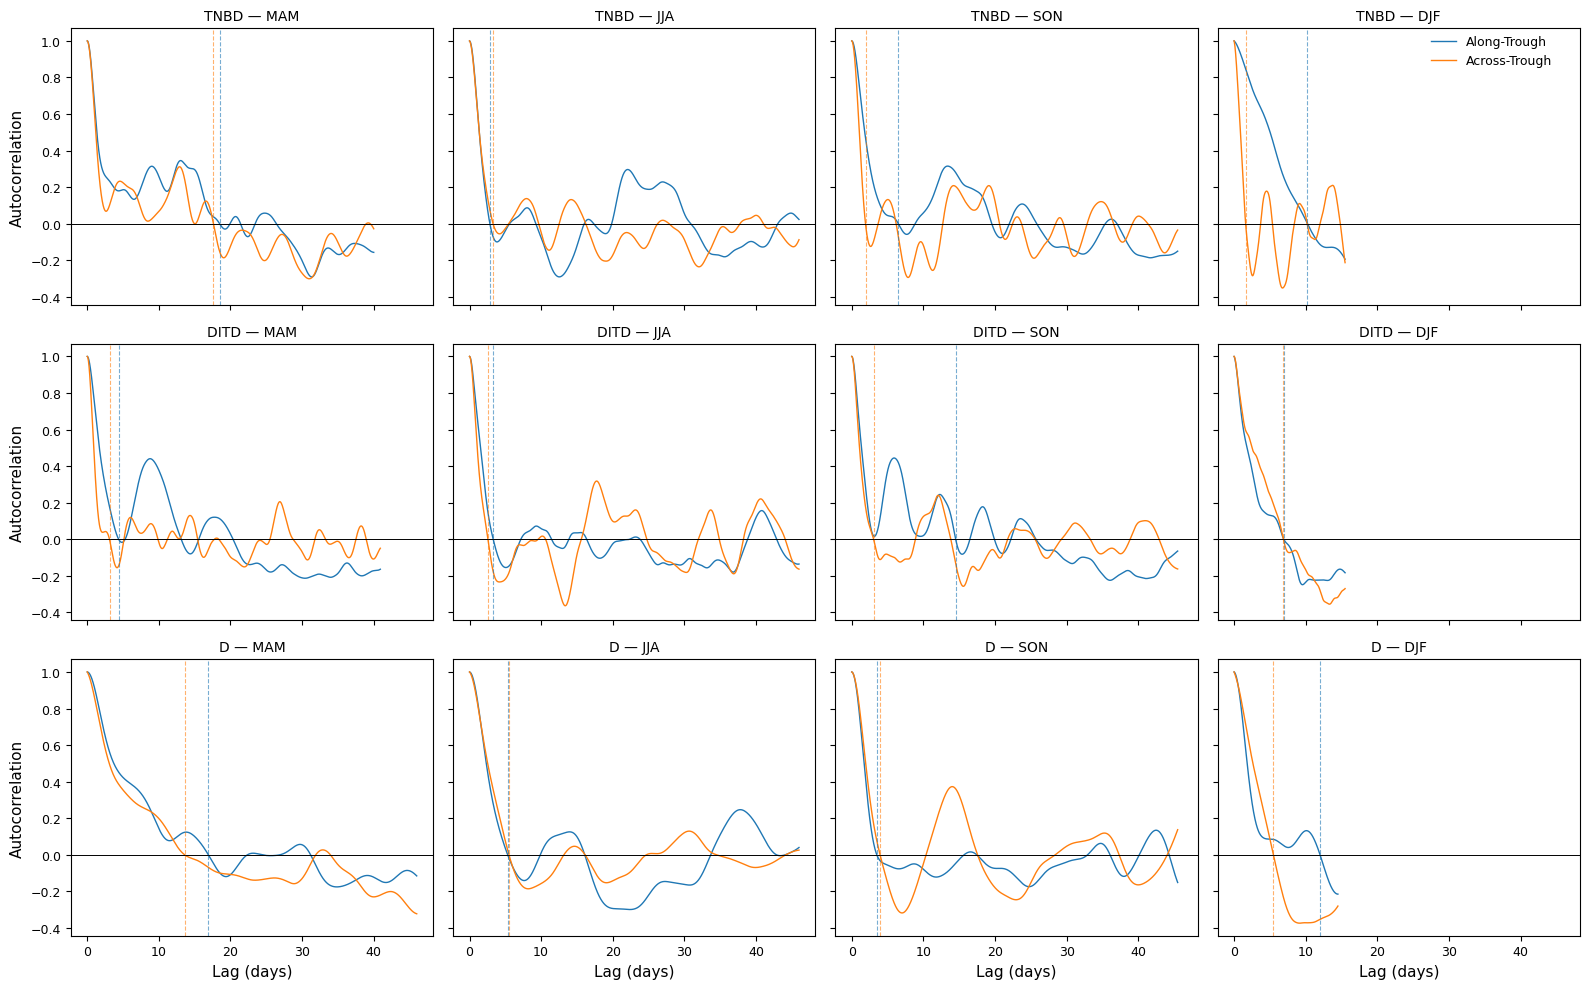

In [ ]:
fig, axes = plt.subplots(len(mooring_order), len(season_order),
                          figsize=(16, 10), sharex=True, sharey=True)

for i, name in enumerate(mooring_order):
    ds = moorings[name]['ds']
    dt = 1 / moorings[name]['fs']

    for j, season in enumerate(season_order):
        ax = axes[i, j]
        months = seasons[season]
        seasonal = ds.sel(time=ds.time.dt.month.isin(months))
        u = seasonal['u_prime'].values
        v = seasonal['v_prime'].values
        N = len(u)

        nlags = min(int(MAX_LAG_DAYS * 86400 / dt), N // 2)

        # same skip logic as the timescale-computation cell
        if N < 2 * nlags or np.any(np.isnan(u)) or np.any(np.isnan(v)):
            ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='gray')
            ax.set_title(f"{name} — {season}", fontsize=10)
            continue

        rho_u = autocorrelation(u, nlags=nlags)
        rho_v = autocorrelation(v, nlags=nlags)
        lag_days = np.arange(len(rho_u)) * dt / 86400

        # pull the already-computed k_star / T_ET from the stored results
        # (recomputed rho here just for plotting, so these should match)
        res = timescale_seasonal[name].get(season)

        ax.plot(lag_days, rho_u, color='tab:blue', lw=1, label='Along-Trough')
        ax.plot(lag_days, rho_v, color='tab:orange', lw=1, label='Across-Trough')
        ax.axhline(0, color='k', lw=0.7)
        

        if res is not None:
            k_star_u_days = res['k_star_u'] * dt / 86400
            k_star_v_days = res['k_star_v'] * dt / 86400
            ax.axvline(k_star_u_days, color='tab:blue', lw=0.8, ls='--', alpha=0.6)
            ax.axvline(k_star_v_days, color='tab:orange', lw=0.8, ls='--', alpha=0.6)

        ax.set_title(f"{name} — {season}", fontsize=10)

        if i == len(mooring_order) - 1:
            ax.set_xlabel('Lag (days)')
        if j == 0:
            ax.set_ylabel(r'Autocorrelation')

# single shared legend instead of repeating per-panel
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, ncol=1, frameon=False, loc='upper right',bbox_to_anchor=(0.98, 0.97))

# fig.suptitle('Seasonal autocorrelation by mooring (dashed = zero-crossing cutoff)', y=1.02)
plt.tight_layout()
# plt.savefig('Seasonal_IntegralTimescale.png', dpi=300, bbox_inches='tight')
plt.show()

### Integral Timescale and Standard Error Sensitivity Analysis on Monthly Basis 

Goal: Understand how integral timescale and standard error estimates change for monthly means. Specifically, I am interested in understanding what is the difference in standard error when calculated using the full record integral timescale versus the monthly integral timescale. Hopefully these differences are small and then I can pick whichever method to use for getting standard error. 

In [2]:
# load in data 

# LOAD IN INTERMEDIATE DATASETS DELL - 30 MIN AVERAGED DATA 
TNBD_ctd_top = xr.open_dataset('data/TNBD_ctd_top_30min.nc')
TNBD_ctd_bot = xr.open_dataset('data/TNBD_ctd_bot_30min.nc')
TNBD_vel_top = xr.open_dataset('data/TNBD_vel_top_30min.nc')
TNBD_vel_bot = xr.open_dataset('data/TNBD_vel_bot_30min.nc')

DITD_ctd_top = xr.open_dataset('data/DITD_ctd_top_30min.nc')
DITD_ctd_bot = xr.open_dataset('data/DITD_ctd_bot_30min.nc')
DITD_vel_top = xr.open_dataset('data/DITD_vel_top_30min.nc')
DITD_vel_bot = xr.open_dataset('data/DITD_vel_bot_30min.nc')      # sensor cut out in june 2018

D_ctd_top = xr.open_dataset('data/D_ctd_top_30min.nc')
D_ctd_mid = xr.open_dataset('data/D_ctd_mid_30min.nc')
# D_ctd_bot = D_ctd_bot.sel(time=time_slice).resample(time=resample).mean()        # this sensor cut out in 2017

# D_vel_top = D_vel_top.sel(time=time_slice).resample(time=resample).mean()        # this sensor cut out end of 2017
D_vel_mid = xr.open_dataset('data/D_vel_mid_30min.nc')
D_vel_bot = xr.open_dataset('data/D_vel_bot_30min.nc')

In [3]:
TNBD_vel_top

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 14064)
Coordinates:
  * time     (time) datetime64[ns] 113kB 2018-03-14 ... 2018-12-31T23:30:00
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...
Data variables:
    u        (time) float64 113kB ...
    v        (time) float64 113kB ...
    w        (time) float64 113kB ...
    pres     (time) float64 113kB ...
    speed    (time) float64 113kB ...
    dir      (time) float64 113kB ...
    u_prime  (time) float64 113kB ...
    v_prime  (time) float64 113kB ...

In [5]:
# import numpy as np
# import pandas as pd
# import xarray as xr
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import sys
# sys.path.append('path/to/your/TNB_tools')  # adjust to your repo path
# import velocity_timescale as vt

# ── MOORING DATASETS ──────────────────────────────────────────────────────────
# Each should be an xarray Dataset with 'u_prime' variable and 'time' coord
# Replace with your actual dataset names
MOORINGS = {
    'DITD': {'ds': DITD_vel_top, 'color': 'tomato',    'dt_hours': 0.5},
    'TNBD': {'ds': TNBD_vel_bot, 'color': 'steelblue', 'dt_hours': 0.5},
    'D':    {'ds': D_vel_bot,    'color': 'seagreen',  'dt_hours': 0.5},
}

# ── HELPER: clean a time series for velocity_timescale.py ────────────────────
def prepare_series(x):
    """Interpolate NaNs so velocity_timescale functions don't error."""
    x = np.asarray(x, dtype=float)
    t = np.arange(len(x))
    finite = np.isfinite(x)
    if finite.sum() < 10:
        return None
    return np.interp(t, t[finite], x[finite])


# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — FULL RECORD INTEGRAL TIMESCALE
# ══════════════════════════════════════════════════════════════════════════════

full_record_results = {}

for name, meta in MOORINGS.items():
    ds       = meta['ds']
    dt_hours = meta['dt_hours']
    dt_s     = dt_hours * 3600.0

    x = prepare_series(ds['u_prime'].values)
    if x is None:
        print(f"{name}: insufficient data"); continue

    # Autocorrelation — search up to 10 days for zero crossing
    nlags_10d = int(20 * 24 / dt_hours)
    rho       = its.autocorrelation(x, nlags=nlags_10d)

    # Two-sided T_int then convert to one-sided T_L (Saunders convention)
    T_int, k_star = its.integral_timescale(rho, dt=dt_s)
    T_L           = its.one_sided_integral_timescale(T_int)   # T_int / 2

    # Full record standard error (Saunders 1987)
    T_record = len(x) * dt_s
    sigma    = np.std(x, ddof=1)
    SE_full  = its.standard_error_saunders(sigma, T_L, T_record)
    N_star   = its.effective_dof(len(x), dt_s, T_int)

    full_record_results[name] = {
        'T_int_s':   T_int,
        'T_int_h':   T_int / 3600,
        'T_int_d':   T_int / 86400,
        'T_L_s':     T_L,
        'T_L_h':     T_L / 3600,
        'T_L_d':     T_L / 86400,
        'k_star':    k_star,
        'N_star':    N_star,
        'sigma':     sigma,
        'SE_full':   SE_full,
        'rho':       rho,
        'N':         len(x),
        'dt_s':      dt_s,
    }

    print(f"\n{'='*55}")
    print(f"{name} — full record")
    print(f"  N:              {len(x)}")
    print(f"  T_int (2-sided): {T_int/3600:.2f} h  ({T_int/86400:.2f} d)")
    print(f"  T_L   (1-sided): {T_L/3600:.2f} h  ({T_L/86400:.2f} d)")
    print(f"  k_star:          {k_star} lags")
    print(f"  N*:              {N_star:.1f}")
    print(f"  sigma:           {sigma:.4f} m/s")
    print(f"  SE (full):       {SE_full:.5f} m/s")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — MONTHLY ESTIMATES
# ══════════════════════════════════════════════════════════════════════════════

monthly_results = {}

for name, meta in MOORINGS.items():
    if name not in full_record_results:
        continue

    ds       = meta['ds']
    dt_hours = meta['dt_hours']
    dt_s     = dt_hours * 3600.0
    fr       = full_record_results[name]   # full record results shorthand

    time     = pd.DatetimeIndex(ds['time'].values)
    x_all    = ds['u_prime'].values.astype(float)
    records  = []

    for month in sorted(time.month.unique()):
        mask    = time.month == month
        x_month = x_all[mask]
        label   = pd.Timestamp(f'2018-{month:02d}-01').strftime('%b')
        n_valid = np.sum(np.isfinite(x_month))

        if n_valid < 20:
            print(f"  {name} {label}: skipping ({n_valid} valid pts)")
            continue

        x_clean  = prepare_series(x_month)
        sigma_mo = np.std(x_clean, ddof=1)
        T_record_mo = len(x_clean) * dt_s

        # ── SE using FULL-RECORD T_L, monthly sigma and record length ─────────
        SE_fullTL = its.standard_error_saunders(
            sigma_mo, fr['T_L_s'], T_record_mo)
        N_star_fullTL = its.effective_dof(len(x_clean), dt_s, fr['T_int_s'])

        # ── Monthly T_L ───────────────────────────────────────────────────────
        try:
            nlags_mo = min(int(20 * 24 / dt_hours), len(x_clean) // 2)
            rho_mo   = its.autocorrelation(x_clean, nlags=nlags_mo)
            T_int_mo, k_star_mo = its.integral_timescale(rho_mo, dt=dt_s)
            T_L_mo   = its.one_sided_integral_timescale(T_int_mo)

            # Guard: T_L longer than record makes no physical sense
            if T_int_mo >= T_record_mo:
                print(f"  {name} {label}: T_int >= T_record — "
                      f"capping at full-record T_L")
                T_int_mo = fr['T_int_s']
                T_L_mo   = fr['T_L_s']
                k_star_mo = fr['k_star']

            SE_monthlyTL  = its.standard_error_saunders(
                sigma_mo, T_L_mo, T_record_mo)
            N_star_monthly = its.effective_dof(
                len(x_clean), dt_s, T_int_mo)

        except ValueError as e:
            print(f"  {name} {label}: ACF issue ({e}) — using full T_L")
            T_int_mo      = fr['T_int_s']
            T_L_mo        = fr['T_L_s']
            k_star_mo     = fr['k_star']
            SE_monthlyTL  = SE_fullTL
            N_star_monthly = N_star_fullTL
            rho_mo        = None

        records.append({
            'month':          label,
            'month_num':      month,
            'n':              len(x_clean),
            'sigma':          sigma_mo,
            'T_int_mo_h':     T_int_mo / 3600,
            'T_int_mo_d':     T_int_mo / 86400,
            'T_L_mo_h':       T_L_mo   / 3600,
            'T_L_mo_d':       T_L_mo   / 86400,
            'k_star_mo':      k_star_mo,
            'N_star_fullTL':  N_star_fullTL,
            'N_star_monthly': N_star_monthly,
            'SE_fullTL':      SE_fullTL,
            'SE_monthlyTL':   SE_monthlyTL,
            'rho_mo':         rho_mo,
            'dt_s':           dt_s,
        })

    monthly_results[name] = pd.DataFrame(records)


# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — DATA TABLE
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*80}")
print("SUMMARY TABLE — Monthly SE estimates")
print(f"{'='*80}")

for name, df in monthly_results.items():
    fr = full_record_results[name]
    print(f"\n{name}  |  Full-record T_L = {fr['T_L_d']:.2f} days  "
          f"|  Full-record SE = {fr['SE_full']:.5f} m/s")
    print(f"{'─'*75}")
    print(f"{'Month':<6} {'N':>6} {'sigma':>8} {'T_L_mo (d)':>12} "
          f"{'N* (full TL)':>14} {'SE (full TL)':>14} "
          f"{'N* (mo TL)':>12} {'SE (mo TL)':>12}")
    print(f"{'─'*75}")
    for _, row in df.iterrows():
        print(f"{row['month']:<6} {row['n']:>6} {row['sigma']:>8.4f} "
              f"{row['T_L_mo_d']:>12.2f} "
              f"{row['N_star_fullTL']:>14.1f} {row['SE_fullTL']:>14.5f} "
              f"{row['N_star_monthly']:>12.1f} {row['SE_monthlyTL']:>12.5f}")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — PLOTS
# ══════════════════════════════════════════════════════════════════════════════

for name, df in monthly_results.items():
    fr    = full_record_results[name]
    color = MOORINGS[name]['color']
    mons  = df['month'].values
    x     = np.arange(len(mons))

    fig = plt.figure(figsize=(16, 14))
    gs  = gridspec.GridSpec(3, 2, hspace=0.42, wspace=0.32,
                             figure=fig)

    # ── A: Full record ACF ────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 0])
    rho_full = fr['rho']
    dt_h     = fr['dt_s'] / 3600
    lags_d   = np.arange(len(rho_full)) * dt_h / 24
    k_star   = fr['k_star']

    ax.plot(lags_d, rho_full, color=color, lw=2, label='Full record ACF')
    ax.fill_between(lags_d[:k_star+1], 0, rho_full[:k_star+1],
                    alpha=0.18, color=color,
                    label=f'T_L = {fr["T_L_d"]:.2f} d')
    ax.axvline(lags_d[k_star], color=color, lw=1.5, ls='--', alpha=0.7,
               label=f'Zero crossing = {lags_d[k_star]:.1f} d')
    ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.4)
    ax.set_xlabel('Lag (days)', fontsize=11)
    ax.set_ylabel('Autocorrelation', fontsize=11)
    ax.set_ylim(-0.5, 1.05)
    ax.set_title(f'[A] Full record ACF — {name}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── B: Monthly ACFs overlaid ──────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 1])
    cmap   = plt.cm.twilight
    n_mo   = len(df)
    colors = [cmap(i / max(n_mo-1, 1)) for i in range(n_mo)]

    for (_, row), c in zip(df.iterrows(), colors):
        if row['rho_mo'] is not None:
            rho_mo = row['rho_mo']
            lags_mo = np.arange(len(rho_mo)) * (row['dt_s']/3600) / 24
            ax.plot(lags_mo, rho_mo, color=c, lw=1.5, alpha=0.85,
                    label=f"{row['month']} ({row['T_L_mo_d']:.1f}d)")

    # Full record ACF for reference
    ax.plot(lags_d, rho_full, color='k', lw=2.5, ls='--',
            label='Full record', zorder=5)
    ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.4)
    ax.set_xlabel('Lag (days)', fontsize=11)
    ax.set_ylabel('Autocorrelation', fontsize=11)
    ax.set_ylim(-0.5, 1.05)
    ax.set_title(f'[B] Monthly ACFs — {name}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right', ncol=2, framealpha=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── C: Monthly T_L vs full-record T_L ────────────────────────────────────
    ax = fig.add_subplot(gs[1, 0])
    ax.bar(x, df['T_L_mo_d'], color=color, alpha=0.7, label='Monthly T_L')
    ax.axhline(fr['T_L_d'], color='k', lw=2, ls='--',
               label=f'Full-record T_L = {fr["T_L_d"]:.2f} d')
    ax.set_xticks(x); ax.set_xticklabels(mons, fontsize=10)
    ax.set_ylabel('T_L (days)', fontsize=11)
    ax.set_title(f'[C] Monthly vs full-record T_L — {name}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── D: N_eff comparison ───────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 1])
    ax.bar(x - 0.2, df['N_star_fullTL'],  width=0.38, color='k',
           alpha=0.5, label='N* (full-record T_L)')
    ax.bar(x + 0.2, df['N_star_monthly'], width=0.38, color=color,
           alpha=0.7, label='N* (monthly T_L)')
    ax.set_xticks(x); ax.set_xticklabels(mons, fontsize=10)
    ax.set_ylabel('N* (effective DOF)', fontsize=11)
    ax.set_title(f'[D] N* comparison — {name}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── E: SE comparison — the key figure ────────────────────────────────────
    ax = fig.add_subplot(gs[2, :])
    ax.bar(x - 0.2, df['SE_fullTL'],    width=0.38, color='k',
           alpha=0.5, label='SE — full-record T_L, monthly σ and N')
    ax.bar(x + 0.2, df['SE_monthlyTL'], width=0.38, color=color,
           alpha=0.7, label='SE — monthly T_L, monthly σ and N')
    ax.axhline(fr['SE_full'], color='k', lw=2, ls='--',
               label=f'SE full record = {fr["SE_full"]:.4f} m/s')
    ax.set_xticks(x); ax.set_xticklabels(mons, fontsize=10)
    ax.set_ylabel('Standard error (m/s)', fontsize=11)
    ax.set_title(f'[E] SE comparison — {name}\n'
                 f'If bars are similar → use full-record T_L for all months',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.suptitle(f'Integral timescale and SE analysis — {name} u_prime',
                 fontsize=13, fontweight='bold')
    plt.savefig(f'timescale_analysis_{name}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

ValueError: ACF never crosses zero within the given lags -- increase nlags in autocorrelation().

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Imports and settings
# ═══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from TNB_tools import Integral_Timescale as its

# Mooring datasets and metadata — adjust dataset names to match yours
MOORINGS = {
    'DITD': {'ds': DITD_vel_top, 'color': 'tomato',    'dt_hours': 0.5},
    'TNBD': {'ds': TNBD_vel_bot, 'color': 'steelblue', 'dt_hours': 0.5},
    'D':    {'ds': D_vel_bot,    'color': 'seagreen',  'dt_hours': 0.5},
}

MAX_LAG_DAYS = 50   # search window for ACF zero crossing

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Helper
# ═══════════════════════════════════════════════════════════════════════════════

def prepare_series(x):
    """Interpolate NaNs so Integral_Timescale functions don't error."""
    x = np.asarray(x, dtype=float)
    t = np.arange(len(x))
    finite = np.isfinite(x)
    if finite.sum() < 10:
        return None
    return np.interp(t, t[finite], x[finite])

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Full record integral timescale and SE
# ═══════════════════════════════════════════════════════════════════════════════

full_record_results = {}

for name, meta in MOORINGS.items():
    ds       = meta['ds']
    dt_hours = meta['dt_hours']
    dt_s     = dt_hours * 3600.0

    x = prepare_series(ds['u_prime'].values)
    if x is None:
        print(f"{name}: insufficient data")
        continue

    nlags_max = min(int(MAX_LAG_DAYS * 24 / dt_hours), len(x) // 2)
    rho       = its.autocorrelation(x, nlags=nlags_max)

    # Integral timescale with fallback if ACF never crosses zero
    try:
        T_int, k_star   = its.integral_timescale(rho, dt=dt_s)
        zero_cross_flag = False
    except ValueError:
        print(f"\n  WARNING [{name}]: ACF did not cross zero in "
              f"{MAX_LAG_DAYS} days — integrating positive area only.")
        positive = rho > 0
        lags_s   = np.arange(len(rho)) * dt_s
        T_int    = 2 * float(np.trapezoid(rho[positive], lags_s[positive]))
        k_star   = int(positive.sum())
        zero_cross_flag = True

    T_L      = its.one_sided_integral_timescale(T_int)
    T_record = len(x) * dt_s
    sigma    = np.std(x, ddof=1)
    SE_full  = its.standard_error_saunders(sigma, T_L, T_record)
    N_star   = its.effective_dof(len(x), dt_s, T_int)

    full_record_results[name] = {
        'T_int_s':         T_int,
        'T_int_h':         T_int / 3600,
        'T_int_d':         T_int / 86400,
        'T_L_s':           T_L,
        'T_L_h':           T_L / 3600,
        'T_L_d':           T_L / 86400,
        'k_star':          k_star,
        'N_star':          N_star,
        'sigma':           sigma,
        'SE_full':         SE_full,
        'rho':             rho,
        'N':               len(x),
        'dt_s':            dt_s,
        'zero_cross_flag': zero_cross_flag,
    }

    flag = "  ⚠ ACF fallback" if zero_cross_flag else ""
    print(f"\n{'='*52}")
    print(f"{name} — full record u_prime{flag}")
    print(f"  N:               {len(x)}")
    print(f"  T_int (2-sided): {T_int/3600:.2f} h  ({T_int/86400:.2f} d)")
    print(f"  T_L   (1-sided): {T_L/3600:.2f} h  ({T_L/86400:.2f} d)")
    print(f"  k_star:          {k_star} lags")
    print(f"  N*:              {N_star:.1f}")
    print(f"  sigma:           {sigma:.4f} cm/s")
    print(f"  SE (full):       {SE_full:.4f} cm/s")


DITD — full record u_prime
  N:               14064
  T_int (2-sided): 156.35 h  (6.51 d)
  T_L   (1-sided): 78.18 h  (3.26 d)
  k_star:          1004 lags
  N*:              45.0
  sigma:           0.0437 cm/s
  SE (full):       0.0065 cm/s

TNBD — full record u_prime
  N:               14064
  T_int (2-sided): 276.94 h  (11.54 d)
  T_L   (1-sided): 138.47 h  (5.77 d)
  k_star:          1521 lags
  N*:              25.4
  sigma:           0.0561 cm/s
  SE (full):       0.0111 cm/s

D — full record u_prime
  N:               14064
  T_int (2-sided): 103.54 h  (4.31 d)
  T_L   (1-sided): 51.77 h  (2.16 d)
  k_star:          828 lags
  N*:              67.9
  sigma:           0.0563 cm/s
  SE (full):       0.0068 cm/s


In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Monthly integral timescales and SE
# ═══════════════════════════════════════════════════════════════════════════════

monthly_results = {}

for name, meta in MOORINGS.items():
    if name not in full_record_results:
        continue

    ds       = meta['ds']
    dt_hours = meta['dt_hours']
    dt_s     = dt_hours * 3600.0
    fr       = full_record_results[name]
    time     = pd.DatetimeIndex(ds['time'].values)
    x_all    = ds['u_prime'].values.astype(float)
    records  = []

    print(f"\n{'='*52}")
    print(f"{name} — monthly breakdown")
    print(f"  Full-record T_L = {fr['T_L_d']:.2f} days")
    print(f"{'─'*52}")

    for month in sorted(time.month.unique()):
        mask    = time.month == month
        x_month = x_all[mask]
        label   = pd.Timestamp(f'2018-{month:02d}-01').strftime('%b')
        n_valid = np.sum(np.isfinite(x_month))

        if n_valid < 20:
            print(f"  {label}: skipping ({n_valid} valid pts)")
            continue

        x_clean     = prepare_series(x_month)
        sigma_mo    = np.std(x_clean, ddof=1)
        T_record_mo = len(x_clean) * dt_s

        # ── SE using full-record T_L ──────────────────────────────────────────
        SE_fullTL     = its.standard_error_saunders(
            sigma_mo, fr['T_L_s'], T_record_mo)
        N_star_fullTL = its.effective_dof(len(x_clean), dt_s, fr['T_int_s'])

        # ── Monthly T_L with fallback ─────────────────────────────────────────
        nlags_mo  = min(int(MAX_LAG_DAYS * 24 / dt_hours), len(x_clean) // 2)
        rho_mo    = its.autocorrelation(x_clean, nlags=nlags_mo)
        zero_flag = False

        try:
            T_int_mo, k_star_mo = its.integral_timescale(rho_mo, dt=dt_s)
            # Guard: T_int > 80% of monthly record is unreliable
            if T_int_mo >= T_record_mo * 0.8:
                print(f"  {label}: T_int ({T_int_mo/86400:.1f}d) ≥ 80% "
                      f"of record — using full-record T_L")
                T_int_mo  = fr['T_int_s']
                k_star_mo = fr['k_star']
                zero_flag = True
        except ValueError:
            print(f"  {label}: ACF no zero crossing — using full-record T_L")
            T_int_mo  = fr['T_int_s']
            k_star_mo = fr['k_star']
            zero_flag = True

        T_L_mo         = its.one_sided_integral_timescale(T_int_mo)
        SE_monthlyTL   = its.standard_error_saunders(
            sigma_mo, T_L_mo, T_record_mo)
        N_star_monthly = its.effective_dof(len(x_clean), dt_s, T_int_mo)

        flag = " ⚠" if zero_flag else ""
        print(f"  {label}: T_L={T_L_mo/24:.1f}d  "
              f"N*_fullTL={N_star_fullTL:.0f}  SE_fullTL={SE_fullTL:.4f}  "
              f"N*_mo={N_star_monthly:.0f}  SE_mo={SE_monthlyTL:.4f}{flag}")

        records.append({
            'month':          label,
            'month_num':      month,
            'n':              len(x_clean),
            'sigma':          sigma_mo,
            'T_int_mo_h':     T_int_mo / 3600,
            'T_int_mo_d':     T_int_mo / 86400,
            'T_L_mo_h':       T_L_mo   / 3600,
            'T_L_mo_d':       T_L_mo   / 86400,
            'k_star_mo':      k_star_mo,
            'N_star_fullTL':  N_star_fullTL,
            'N_star_monthly': N_star_monthly,
            'SE_fullTL':      SE_fullTL,
            'SE_monthlyTL':   SE_monthlyTL,
            'rho_mo':         rho_mo,
            'dt_s':           dt_s,
            'fallback':       zero_flag,
        })

    monthly_results[name] = pd.DataFrame(records)


DITD — monthly breakdown
  Full-record T_L = 3.26 days
────────────────────────────────────────────────────
  Mar: T_L=2483.8d  N*_fullTL=3  SE_fullTL=0.0143  N*_mo=13  SE_mo=0.0066
  Apr: T_L=4605.5d  N*_fullTL=5  SE_fullTL=0.0169  N*_mo=12  SE_mo=0.0106
  May: T_L=3791.5d  N*_fullTL=5  SE_fullTL=0.0120  N*_mo=15  SE_mo=0.0068
  Jun: T_L=3371.4d  N*_fullTL=5  SE_fullTL=0.0170  N*_mo=16  SE_mo=0.0091
  Jul: T_L=4136.1d  N*_fullTL=5  SE_fullTL=0.0227  N*_mo=13  SE_mo=0.0135
  Aug: T_L=3457.7d  N*_fullTL=5  SE_fullTL=0.0207  N*_mo=16  SE_mo=0.0113
  Sep: T_L=2388.9d  N*_fullTL=5  SE_fullTL=0.0280  N*_mo=23  SE_mo=0.0126
  Oct: T_L=3609.0d  N*_fullTL=5  SE_fullTL=0.0151  N*_mo=15  SE_mo=0.0084
  Nov: T_L=3339.7d  N*_fullTL=5  SE_fullTL=0.0161  N*_mo=16  SE_mo=0.0086
  Dec: T_L=6034.0d  N*_fullTL=5  SE_fullTL=0.0090  N*_mo=9  SE_mo=0.0065

TNBD — monthly breakdown
  Full-record T_L = 5.77 days
────────────────────────────────────────────────────
  Mar: T_L=2986.6d  N*_fullTL=2  SE_fullTL=

In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Summary data table
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*80}")
print("SUMMARY TABLE — Full record")
print(f"{'='*80}")
print(f"{'Mooring':<8} {'T_L (h)':>9} {'T_L (d)':>9} {'N*':>7} "
      f"{'sigma':>8} {'SE':>8}")
print(f"{'─'*54}")
for name, res in full_record_results.items():
    flag = " ⚠" if res['zero_cross_flag'] else ""
    print(f"{name:<8} {res['T_L_h']:>9.2f} {res['T_L_d']:>9.2f} "
          f"{res['N_star']:>7.1f} {res['sigma']:>8.4f} "
          f"{res['SE_full']:>8.4f}{flag}")

print(f"\n{'='*80}")
print("SUMMARY TABLE — Monthly SE comparison")
print(f"{'='*80}")

for name, df in monthly_results.items():
    fr = full_record_results[name]
    print(f"\n{name}  |  Full-record T_L = {fr['T_L_d']:.2f} d  "
          f"|  Full-record SE = {fr['SE_full']:.4f} cm/s")
    print(f"{'─'*72}")
    print(f"{'Month':<6} {'N':>6} {'sigma':>8} {'T_L_mo(d)':>11} "
          f"{'N*(fullTL)':>12} {'SE(fullTL)':>12} "
          f"{'N*(moTL)':>10} {'SE(moTL)':>10} {'Flag':>5}")
    print(f"{'─'*72}")
    for _, row in df.iterrows():
        flag = "⚠" if row['fallback'] else ""
        print(f"{row['month']:<6} {row['n']:>6} {row['sigma']:>8.4f} "
              f"{row['T_L_mo_d']:>11.2f} "
              f"{row['N_star_fullTL']:>12.1f} {row['SE_fullTL']:>12.4f} "
              f"{row['N_star_monthly']:>10.1f} {row['SE_monthlyTL']:>10.4f} "
              f"{flag:>5}")


SUMMARY TABLE — Full record
Mooring    T_L (h)   T_L (d)      N*    sigma       SE
──────────────────────────────────────────────────────
DITD         78.18      3.26    45.0   0.0437   0.0065
TNBD        138.47      5.77    25.4   0.0561   0.0111
D            51.77      2.16    67.9   0.0563   0.0068

SUMMARY TABLE — Monthly SE comparison

DITD  |  Full-record T_L = 3.26 d  |  Full-record SE = 0.0065 cm/s
────────────────────────────────────────────────────────────────────────
Month       N    sigma   T_L_mo(d)   N*(fullTL)   SE(fullTL)   N*(moTL)   SE(moTL)  Flag
────────────────────────────────────────────────────────────────────────
Mar       864   0.0238        0.69          2.8       0.0143       13.0     0.0066      
Apr      1440   0.0362        1.28          4.6       0.0169       11.7     0.0106      
May      1488   0.0261        1.05          4.8       0.0120       14.7     0.0068      
Jun      1440   0.0365        0.94          4.6       0.0170       16.0     0.0091     

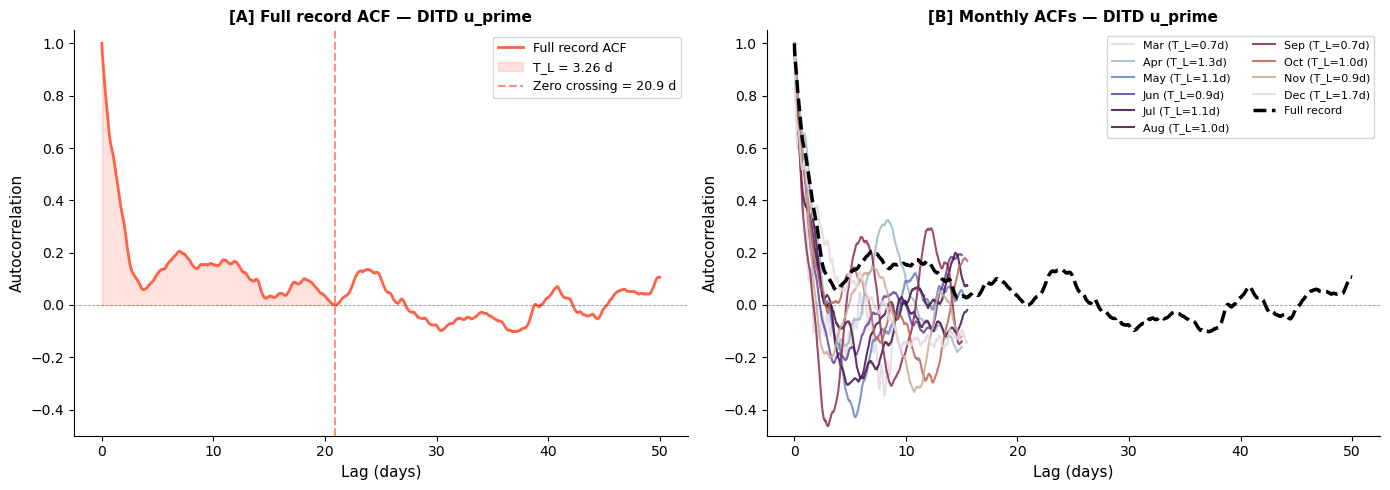

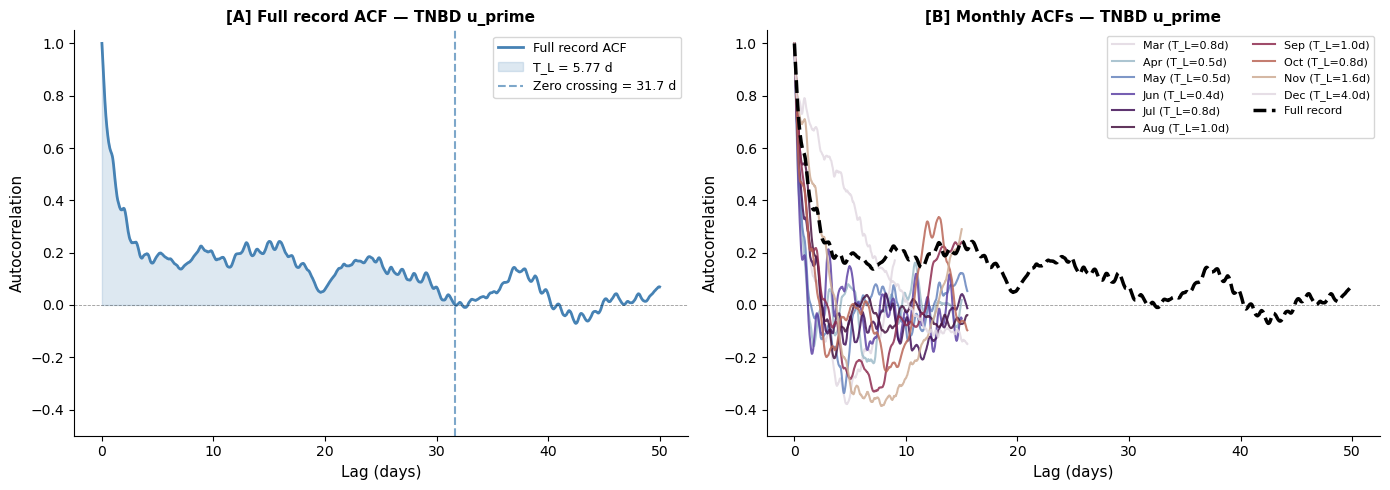

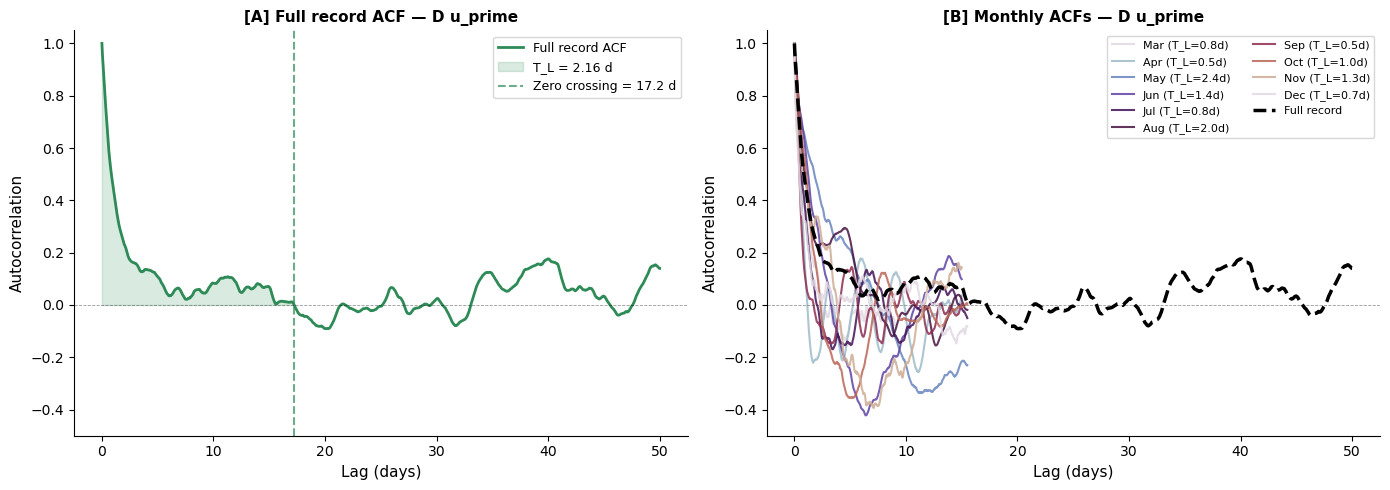

In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — ACF plots (full record + monthly overlaid)
# ═══════════════════════════════════════════════════════════════════════════════

for name, df in monthly_results.items():
    fr    = full_record_results[name]
    color = MOORINGS[name]['color']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: full record ACF ─────────────────────────────────────────────────
    ax      = axes[0]
    rho_f   = fr['rho']
    dt_h    = fr['dt_s'] / 3600
    lags_d  = np.arange(len(rho_f)) * dt_h / 24
    k_star  = fr['k_star']

    ax.plot(lags_d, rho_f, color=color, lw=2, label='Full record ACF')
    ax.fill_between(lags_d[:k_star+1], 0, rho_f[:k_star+1],
                    alpha=0.18, color=color,
                    label=f'T_L = {fr["T_L_d"]:.2f} d')
    ax.axvline(lags_d[min(k_star, len(lags_d)-1)],
               color=color, lw=1.5, ls='--', alpha=0.7,
               label=f'Zero crossing = {lags_d[min(k_star,len(lags_d)-1)]:.1f} d')
    ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.4)
    ax.set_xlabel('Lag (days)', fontsize=11)
    ax.set_ylabel('Autocorrelation', fontsize=11)
    ax.set_ylim(-0.5, 1.05)
    ax.set_title(f'[A] Full record ACF — {name} u_prime',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── Right: monthly ACFs overlaid ──────────────────────────────────────────
    ax     = axes[1]
    cmap   = plt.cm.twilight
    n_mo   = len(df)
    colors = [cmap(i / max(n_mo-1, 1)) for i in range(n_mo)]

    for (_, row), c in zip(df.iterrows(), colors):
        rho_mo  = row['rho_mo']
        lags_mo = np.arange(len(rho_mo)) * (row['dt_s']/3600) / 24
        ax.plot(lags_mo, rho_mo, color=c, lw=1.5, alpha=0.85,
                label=f"{row['month']} (T_L={row['T_L_mo_d']:.1f}d)")

    ax.plot(lags_d, rho_f, color='k', lw=2.5, ls='--',
            label='Full record', zorder=5)
    ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.4)
    ax.set_xlabel('Lag (days)', fontsize=11)
    ax.set_ylabel('Autocorrelation', fontsize=11)
    ax.set_ylim(-0.5, 1.05)
    ax.set_title(f'[B] Monthly ACFs — {name} u_prime',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right', ncol=2, framealpha=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'acf_{name}_u_prime.png', dpi=150, bbox_inches='tight')
    plt.show()

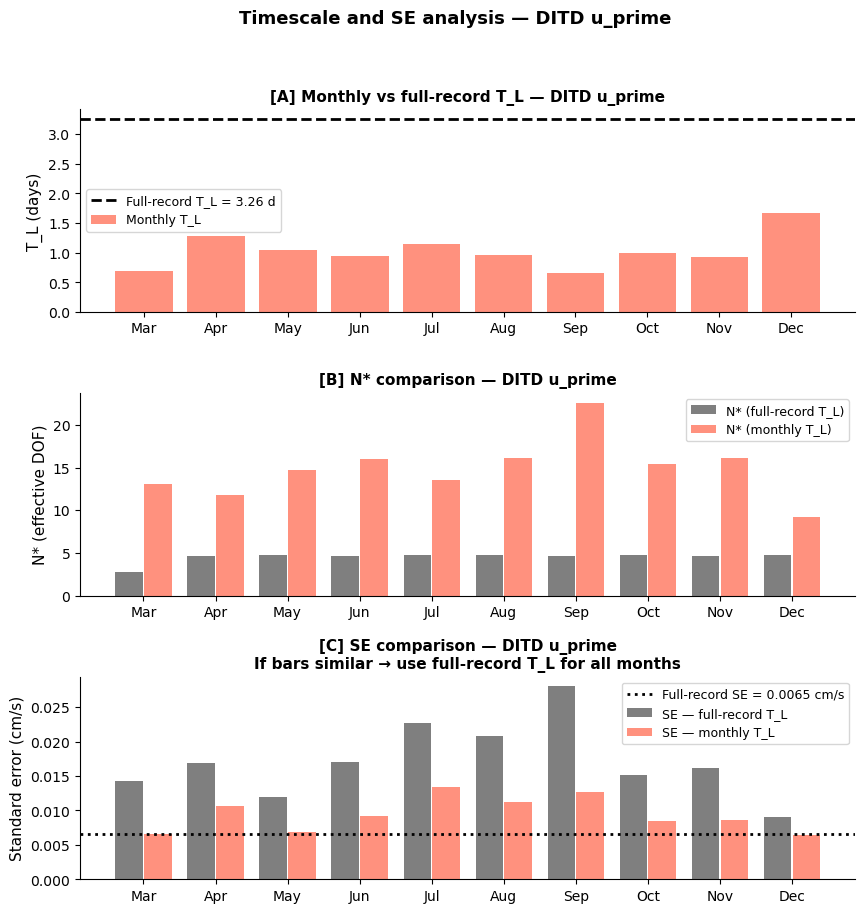

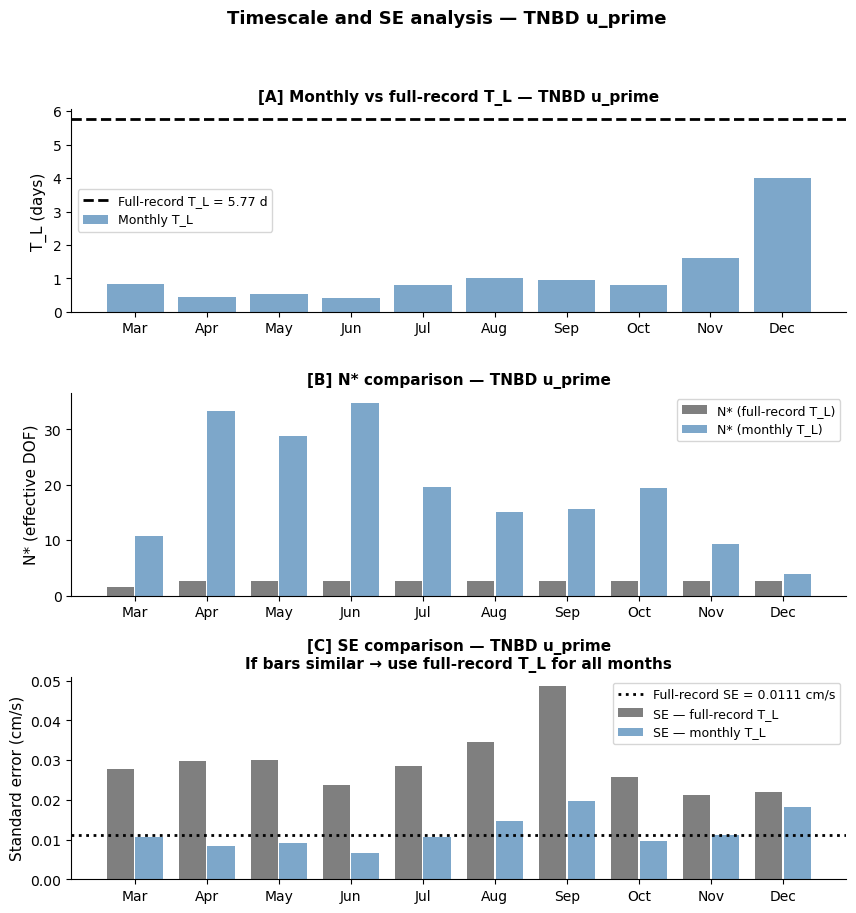

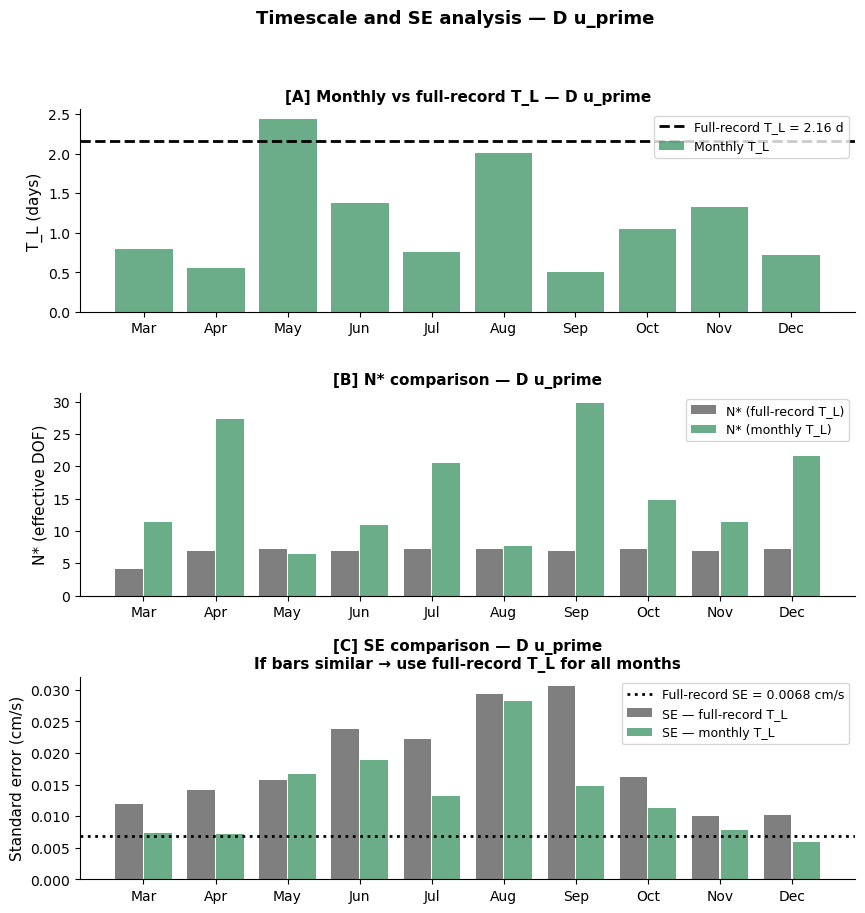

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — SE comparison plots
# ═══════════════════════════════════════════════════════════════════════════════

for name, df in monthly_results.items():
    fr    = full_record_results[name]
    color = MOORINGS[name]['color']
    mons  = df['month'].values
    x     = np.arange(len(mons))

    fig, axes = plt.subplots(3, 1, figsize=(10, 10),
                              gridspec_kw={'hspace': 0.4})

    # ── A: Monthly T_L vs full-record T_L ────────────────────────────────────
    ax = axes[0]
    ax.bar(x, df['T_L_mo_d'], color=color, alpha=0.7, label='Monthly T_L')
    ax.axhline(fr['T_L_d'], color='k', lw=2, ls='--',
               label=f'Full-record T_L = {fr["T_L_d"]:.2f} d')
    # Mark fallback months
    for i, (_, row) in enumerate(df.iterrows()):
        if row['fallback']:
            ax.text(i, df['T_L_mo_d'].max() * 0.95, '⚠',
                    ha='center', fontsize=10, color='gray')
    ax.set_xticks(x); ax.set_xticklabels(mons, fontsize=10)
    ax.set_ylabel('T_L (days)', fontsize=11)
    ax.set_title(f'[A] Monthly vs full-record T_L — {name} u_prime',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── B: N_eff comparison ───────────────────────────────────────────────────
    ax = axes[1]
    ax.bar(x - 0.2, df['N_star_fullTL'],  width=0.38,
           color='k', alpha=0.5, label='N* (full-record T_L)')
    ax.bar(x + 0.2, df['N_star_monthly'], width=0.38,
           color=color, alpha=0.7, label='N* (monthly T_L)')
    ax.set_xticks(x); ax.set_xticklabels(mons, fontsize=10)
    ax.set_ylabel('N* (effective DOF)', fontsize=11)
    ax.set_title(f'[B] N* comparison — {name} u_prime',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── C: SE comparison — key figure ────────────────────────────────────────
    ax = axes[2]
    ax.bar(x - 0.2, df['SE_fullTL'],    width=0.38,
           color='k', alpha=0.5,
           label='SE — full-record T_L')
    ax.bar(x + 0.2, df['SE_monthlyTL'], width=0.38,
           color=color, alpha=0.7,
           label='SE — monthly T_L')
    ax.axhline(fr['SE_full'], color='k', lw=2, ls=':',
               label=f'Full-record SE = {fr["SE_full"]:.4f} cm/s')
    ax.set_xticks(x); ax.set_xticklabels(mons, fontsize=10)
    ax.set_ylabel('Standard error (cm/s)', fontsize=11)
    ax.set_title(f'[C] SE comparison — {name} u_prime\n'
                 f'If bars similar → use full-record T_L for all months',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.suptitle(f'Timescale and SE analysis — {name} u_prime',
                 fontsize=13, fontweight='bold')
    plt.savefig(f'timescale_SE_{name}_u_prime.png',
                dpi=150, bbox_inches='tight')
    plt.show()

In [24]:
# ── Diagnostic: how variable are the monthly T_L estimates? ──────────────────
# High CV (coefficient of variation) = monthly T_L estimates are noisy
# = full-record T_L is more reliable

print("Stability of monthly T_L estimates:")
print(f"{'Mooring':<8} {'T_L_full (d)':>14} {'T_L_mo mean (d)':>17} "
      f"{'T_L_mo std (d)':>16} {'CV (%)':>8} {'Recommendation'}")
print('─' * 80)

for name, df in monthly_results.items():
    fr      = full_record_results[name]
    # Exclude fallback months from the monthly stats
    # (those just repeat the full-record value anyway)
    valid   = df[~df['fallback']]['T_L_mo_d']
    if len(valid) < 2:
        print(f"{name:<8}: insufficient non-fallback months")
        continue
    mo_mean = valid.mean()
    mo_std  = valid.std()
    cv      = 100 * mo_std / mo_mean

    if cv > 50:
        rec = "Use full-record T_L (monthly too noisy)"
    elif cv > 25:
        rec = "Either defensible — note in methods"
    else:
        rec = "Monthly T_L reasonable"

    print(f"{name:<8} {fr['T_L_d']:>14.2f} {mo_mean:>17.2f} "
          f"{mo_std:>16.2f} {cv:>8.1f}%  {rec}")

print()
print("CV > 50% → monthly T_L estimates vary too much month-to-month")
print("         → full-record T_L is more stable and defensible")
print("CV < 25% → monthly T_L is consistent → either approach justified")

Stability of monthly T_L estimates:
Mooring    T_L_full (d)   T_L_mo mean (d)   T_L_mo std (d)   CV (%) Recommendation
────────────────────────────────────────────────────────────────────────────────
DITD               3.26              1.03             0.29     28.3%  Either defensible — note in methods
TNBD               5.77              1.14             1.06     92.7%  Use full-record T_L (monthly too noisy)
D                  2.16              1.15             0.64     56.0%  Use full-record T_L (monthly too noisy)

CV > 50% → monthly T_L estimates vary too much month-to-month
         → full-record T_L is more stable and defensible
CV < 25% → monthly T_L is consistent → either approach justified


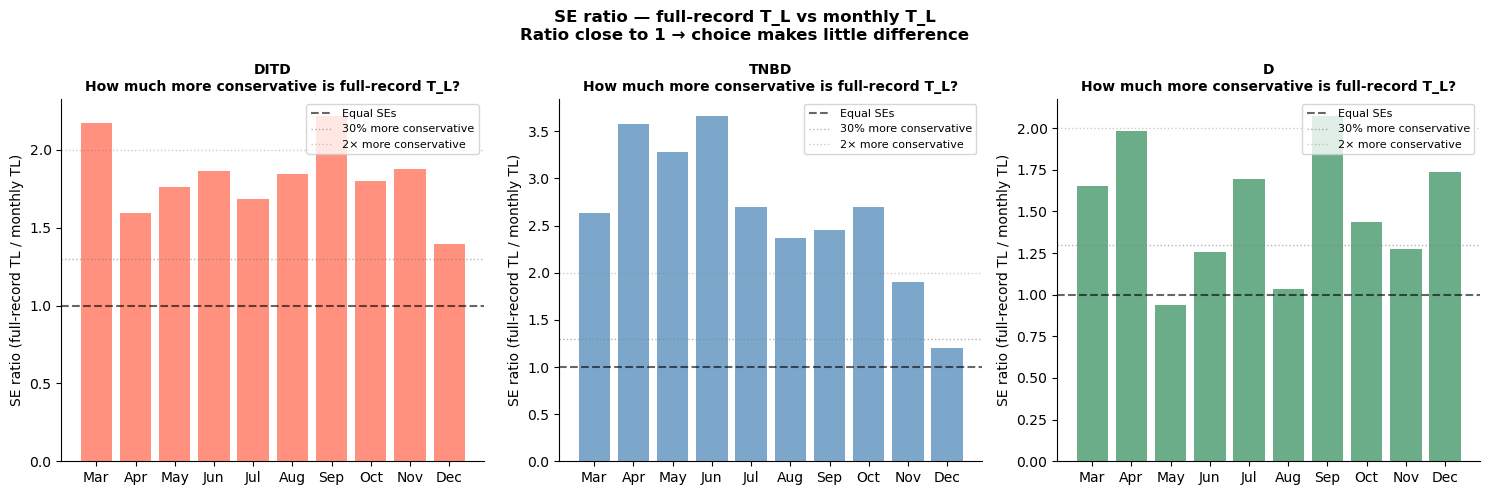

In [25]:
# ── Visual comparison: how much does the SE choice actually matter? ───────────
# If the two SE estimates are within ~30% of each other the choice
# makes little practical difference to your error bars

fig, axes = plt.subplots(1, len(monthly_results), figsize=(5*len(monthly_results), 5),
                          sharey=False)
if len(monthly_results) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, monthly_results.items()):
    color = MOORINGS[name]['color']
    x     = np.arange(len(df))
    mons  = df['month'].values

    # Ratio of SE_fullTL / SE_monthlyTL
    # Values > 1 mean full-record is more conservative
    ratio = df['SE_fullTL'] / df['SE_monthlyTL']

    bars = ax.bar(x, ratio, color=color, alpha=0.7)
    ax.axhline(1.0, color='k', lw=1.5, ls='--', alpha=0.6,
               label='Equal SEs')
    ax.axhline(1.3, color='gray', lw=1, ls=':', alpha=0.6,
               label='30% more conservative')
    ax.axhline(2.0, color='gray', lw=1, ls=':', alpha=0.4,
               label='2× more conservative')

    # Annotate fallback months
    for i, (_, row) in enumerate(df.iterrows()):
        if row['fallback']:
            ax.text(i, ratio.iloc[i] + 0.02, '⚠',
                    ha='center', fontsize=9, color='gray')

    ax.set_xticks(x); ax.set_xticklabels(mons, fontsize=10)
    ax.set_ylabel('SE ratio (full-record TL / monthly TL)', fontsize=10)
    ax.set_title(f'{name}\nHow much more conservative is full-record T_L?',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('SE ratio — full-record T_L vs monthly T_L\n'
             'Ratio close to 1 → choice makes little difference',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('SE_ratio_comparison.png', dpi=150, bbox_inches='tight')
plt.show()